<a href="https://colab.research.google.com/github/pawarisang258-2/SC663402_DW/blob/main/SC663402_Pandas_Review_pawarisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

ุ🤗ึ673020258-2 ปวริศาโง่นสูงเนิน

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!


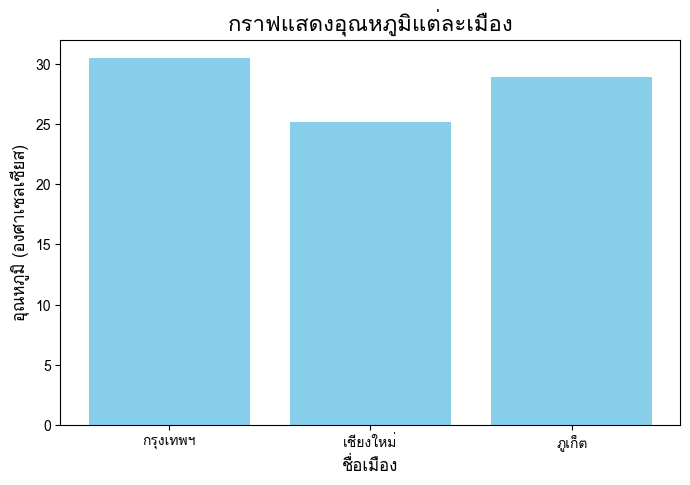

In [1]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [2]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [3]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [4]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [5]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [6]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [7]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [8]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


###ตอบ

เซลล์ 1.1

s["a"] กับ s.iloc[0] ได้ค่า 10 เหมือนกัน ต่างกันตรงที่อันแรกเลือกจากชื่อ index แต่อันที่สองเลือกจากตำแหน่ง ส่วน s[["a","c"]] เลือกหลายค่าเลยได้ออกมาเป็น Series 2 แถว ถ้ารู้ชื่อ index ก็เลือกจากชื่อได้เลย แต่ถ้าจะเลือกตามลำดับก็ใช้ iloc

เซลล์ 1.2

df["city"] ได้เป็น Series ขนาด (2075,) แต่ df[["city"]] ได้เป็น DataFrame ขนาด (2075,1) ข้อมูลเหมือนกันแต่รูปแบบต่างกัน ถ้าจะเอาคอลัมน์เดียวมาใช้ทั่วไปใช้แบบแรกได้ แต่ถ้าอยากให้ยังเป็น DataFrame อยู่ก็ใช้แบบสองวงเล็บ

เซลล์ 1.3

df.loc[0:3] ได้ 4 แถว เพราะรวมแถวที่ label เป็น 3 ด้วย แต่ df.iloc[0:3] ได้ 3 แถว เพราะไม่รวมตำแหน่งสุดท้าย loc จะอิงจาก label ส่วน iloc จะอิงจากตำแหน่ง

เซลล์ 1.4

count() กับ size() ใช้นับเหมือนกัน แต่ count() จะไม่นับค่าที่เป็น missing ในคอลัมน์ที่เลือก ส่วน size() จะนับทุกแถว เห็นได้จาก Beijing ที่ count() ได้ 89 แต่ size() ได้ 90 แสดงว่ามี temperature_c หายไป 1 ค่า

เซลล์ 1.5

สองอันนี้หาค่าเฉลี่ย temperature_c แยกตามเมืองเหมือนกัน ค่าที่ได้ก็เหมือนกัน ต่างแค่แบบแรกได้เป็น Series ส่วนแบบสองวงเล็บได้เป็น DataFrame ถ้าจะใช้แบบง่าย ๆ ใช้ Series แต่ถ้าจะเอาไปทำต่อเป็นตารางก็ใช้ DataFrame

เซลล์ 1.6

a + b จะเอาค่าที่ index ชื่อเดียวกันมาบวกกัน เลยได้ x=31, y=22, z=13 แต่พอใช้ .to_numpy() แล้ว index จะหายไป เลยบวกตามตำแหน่งแทนและได้ [11, 22, 33] ถ้า index มีความหมายควรบวกแบบ Series มากกว่า

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [9]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [10]:
# คำตอบข้อ 2.1

rain_by_city = df.groupby("city")["rainfall_mm"].sum()

print("ปริมาณฝนรวมของแต่ละเมือง")
display(rain_by_city)

print("\n3 เมืองที่มีปริมาณฝนรวมสูงสุด")
display(rain_by_city.nlargest(3))

rain_share = (rain_by_city / rain_by_city.sum() * 100).round(2)

print("\nสัดส่วนปริมาณฝนของแต่ละเมือง (%)")
display(rain_share)

above_avg = (rain_by_city > rain_by_city.mean()).sum()

print("\nจำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย =", above_avg)

ปริมาณฝนรวมของแต่ละเมือง


,rainfall_mm
city,
Auckland,351.9
Bangkok,685.6
Beijing,250.1
Berlin,268.4
Buenos Aires,305.1
Cairo,123.0
Cape Town,239.3
Chiang Mai,435.6
Lagos,652.8



3 เมืองที่มีปริมาณฝนรวมสูงสุด


,rainfall_mm
city,
Singapore,870.4
Bangkok,685.6
Lagos,652.8



สัดส่วนปริมาณฝนของแต่ละเมือง (%)


,rainfall_mm
city,
Auckland,4.22
Bangkok,8.21
Beijing,3.00
Berlin,3.21
Buenos Aires,3.65
Cairo,1.47
Cape Town,2.87
Chiang Mai,5.22
Lagos,7.82



จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย = 8


ฝนรวมสูงสุด 3 เมือง: Singapore 870.4, Bangkok 685.6, Lagos 652.8

สัดส่วนปริมาณฝนครบทุกเมือง

เมืองที่มีฝนรวมสูงกว่าค่าเฉลี่ย = 8 เมือง

### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [11]:
# คำตอบข้อ 2.2

city_profile = (
    df.groupby("city")
      .agg(
          country=("country", lambda x: x.mode().iloc[0]),
          region=("region", lambda x: x.mode().iloc[0]),
          n_records=("city", "size"),
          avg_temp=("temperature_c", "mean"),
          total_rain=("rainfall_mm", "sum")
      )
      .reset_index()
)

city_profile["avg_temp"] = city_profile["avg_temp"].round(2)
city_profile["total_rain"] = city_profile["total_rain"].round(2)

display(city_profile)

,city,country,region,n_records,avg_temp,total_rain
0,Auckland,New Zealand,Oceania,90,17.80,351.9
1,Bangkok,Thailand,Asia,91,32.45,685.6
2,Beijing,China,Asia,90,15.60,250.1
3,Berlin,Germany,Europe,90,12.38,268.4
4,Buenos Aires,Argentina,South America,90,19.17,305.1
5,Cairo,Egypt,Africa,91,26.09,123.0
6,Cape Town,South Africa,Africa,90,30.16,239.3
7,Chiang Mai,Thailand,Asia,91,29.68,435.6
8,Lagos,Nigeria,Africa,90,29.49,652.8
9,Lima,Peru,South America,90,21.49,180.3


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [12]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [13]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [14]:
# คำตอบข้อ 3.1

df_31 = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=[
        "date",
        "city",
        "region",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm"
    ],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={
        "city": "category",
        "region": "category"
    },
    index_col="city"
)

print(df_31.dtypes)
print()
df_31.info()


date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [15]:
# คำตอบข้อ 3.2

normal_df = pd.read_csv(BASE + "world_weather_sample.csv")

normal_memory = normal_df.memory_usage(deep=True).sum()
optimized_memory = df_31.memory_usage(deep=True).sum()

reduction_pct = (
    (normal_memory - optimized_memory)
    / normal_memory * 100
)

print("Memory ตารางปกติ =", normal_memory, "bytes")
print("Memory ตารางข้อ 3.1 =", optimized_memory, "bytes")
print("ลดลง =", round(reduction_pct, 2), "%")

print("\nMemory แยกตามคอลัมน์ของตารางปกติ")
display(normal_df.memory_usage(deep=True))

print("\nMemory แยกตามคอลัมน์ของตารางข้อ 3.1")
display(df_31.memory_usage(deep=True))

Memory ตารางปกติ = 571645 bytes
Memory ตารางข้อ 3.1 = 72917 bytes
ลดลง = 87.24 %

Memory แยกตามคอลัมน์ของตารางปกติ


,0
Index,132
record_id,16600
date,122425
city,116920
country,114937
region,117631
temperature_c,16600
humidity_pct,16600
rainfall_mm,16600
wind_speed_kmh,16600



Memory แยกตามคอลัมน์ของตารางข้อ 3.1


,0
Index,3927
date,16600
region,2590
temperature_c,16600
humidity_pct,16600
rainfall_mm,16600


ตารางปกติใช้ memory 571,645 bytes แต่ตารางจากข้อ 3.1 ใช้ 72,917 bytes เลยลดลงประมาณ 87.24%

ที่ลดลงเยอะเพราะเราเลือกมาแค่คอลัมน์ที่จำเป็น แล้วเปลี่ยน city กับ region ให้เป็น category ซึ่งใช้พื้นที่น้อยกว่าการเก็บเป็นข้อความปกติ

อีกอย่างคือคอลัมน์ที่ไม่ได้ใช้ เช่น country, wind_speed_kmh และ pressure_hpa ก็ไม่ได้ถูกโหลดเข้ามา เลยช่วยลด memory ลงไปอีก

### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [16]:
# คำตอบข้อ 3.3

max_temp = None
min_temp = None

city_sum = {}
city_count = {}

for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    chunksize=500,
    na_values=[999, -999]
):
    # อุณหภูมิสูงสุดและต่ำสุดของแต่ละก้อน
    chunk_max = chunk["temperature_c"].max()
    chunk_min = chunk["temperature_c"].min()

    if max_temp is None or chunk_max > max_temp:
        max_temp = chunk_max

    if min_temp is None or chunk_min < min_temp:
        min_temp = chunk_min

    # สะสม sum และ count ของแต่ละเมือง
    grouped = chunk.groupby("city")["temperature_c"].agg(["sum", "count"])

    for city, row in grouped.iterrows():
        city_sum[city] = city_sum.get(city, 0) + row["sum"]
        city_count[city] = city_count.get(city, 0) + row["count"]

# คำนวณค่าเฉลี่ยรายเมือง
city_avg = pd.Series({
    city: city_sum[city] / city_count[city]
    for city in city_sum
}).sort_index()

print("อุณหภูมิสูงสุด =", max_temp)
print("อุณหภูมิต่ำสุด =", min_temp)

print("\nอุณหภูมิเฉลี่ยรายเมือง")
display(city_avg.round(2))

อุณหภูมิสูงสุด = 39.2
อุณหภูมิต่ำสุด = -88.0

อุณหภูมิเฉลี่ยรายเมือง


,0
Auckland,17.80
Bangkok,32.45
Beijing,15.60
Berlin,12.38
Buenos Aires,19.17
Cairo,26.09
Cape Town,19.15
Chiang Mai,29.68
Lagos,29.49
Lima,21.49


ค่าเฉลี่ยของแต่ละ chunk เอามาเฉลี่ยกันตรง ๆ ไม่ได้ เพราะแต่ละ chunk อาจมีจำนวนข้อมูลของแต่ละเมืองไม่เท่ากัน
ถ้าเอาค่าเฉลี่ยมาเฉลี่ยอีกทีจะทำให้น้ำหนักของแต่ละก้อนเท่ากันทั้งที่จำนวนข้อมูลไม่เท่ากัน
วิธีที่ถูกคือสะสมผลรวมของอุณหภูมิและจำนวนข้อมูลของแต่ละเมืองจากทุก chunk ก่อน แล้วค่อยเอาผลรวมหารด้วยจำนวนข้อมูลทั้งหมดของเมืองนั้น

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [18]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [19]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [20]:
# คำตอบข้อ 4.1

summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
    "example_value": df.apply(lambda col: col.dropna().iloc[0])
})

summary = summary.sort_values("n_missing", ascending=False)

display(summary)

,dtype,n_missing,pct_missing,n_unique,example_value
humidity_pct,float64,82,3.95,544,72.6
rainfall_mm,float64,62,2.99,164,6.3
wind_speed_kmh,float64,41,1.98,278,15.9
pressure_hpa,float64,32,1.54,294,1005.4
temperature_c,float64,20,0.96,331,15.7
record_id,int64,0,0.00,2070,983
date,object,0,0.00,90,2025-03-24
region,object,0,0.00,6,North America
city,object,0,0.00,23,New York
country,object,0,0.00,28,USA


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [21]:
# คำตอบข้อ 4.2

temp_abnormal = (
    df["temperature_c"].notna()
    & ~df["temperature_c"].between(-60, 60)
)

humidity_abnormal = (
    df["humidity_pct"].notna()
    & ~df["humidity_pct"].between(0, 100)
)

print("จำนวนแถวที่ temperature_c ผิดปกติ =", temp_abnormal.sum())
print("จำนวนแถวที่ humidity_pct ผิดปกติ =", humidity_abnormal.sum())

any_abnormal = temp_abnormal | humidity_abnormal

print("จำนวนแถวที่ผิดปกติอย่างน้อย 1 คอลัมน์ =", any_abnormal.sum())

จำนวนแถวที่ temperature_c ผิดปกติ = 5
จำนวนแถวที่ humidity_pct ผิดปกติ = 3
จำนวนแถวที่ผิดปกติอย่างน้อย 1 คอลัมน์ = 8


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [22]:
# คำตอบข้อ 4.3

#---------4.3.1-----------

country_check = (
    df.assign(country_clean=df["country"].str.strip().str.lower())
      .groupby("country_clean")["country"]
      .unique()
)

country_check = country_check[country_check.apply(len) > 1]

display(country_check)

,country
country_clean,
argentina,"[Argentina, ARGENTINA]"
canada,"[Canada, CANADA]"
germany,"[Germany, GERMANY]"
japan,"[Japan, JAPAN]"
kenya,"[Kenya, KENYA]"
new zealand,"[New Zealand, NEW ZEALAND]"
singapore,"[Singapore, SINGAPORE]"


In [23]:
#---------4.3.2-----------

country_title = df["country"].str.strip().str.title()

print("ค่าหลังใช้ str.title():")
print(sorted(country_title.unique()))

ค่าหลังใช้ str.title():
['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'Egypt', 'France', 'Germany', 'India', 'Japan', 'Kenya', 'Mexico', 'New Zealand', 'Nigeria', 'Peru', 'Russia', 'Singapore', 'South Africa', 'Thailand', 'Uk', 'Usa']


str.title() ช่วยทำให้ชื่อประเทศที่ตัวพิมพ์ใหญ่เล็กไม่เหมือนกันดูเป็นรูปแบบเดียวกันได้ แต่มีปัญหากับชื่อประเทศที่เป็นตัวย่อ เช่น UK จะกลายเป็น Uk และ USA จะกลายเป็น Usa ซึ่งไม่ถูกต้อง เพราะตัวย่อพวกนี้ควรเป็นตัวพิมพ์ใหญ่ทั้งหมด

In [24]:
#---------4.3.3-----------

country_map = {
    "argentina": "Argentina",
    "australia": "Australia",
    "brazil": "Brazil",
    "canada": "Canada",
    "china": "China",
    "egypt": "Egypt",
    "france": "France",
    "germany": "Germany",
    "india": "India",
    "japan": "Japan",
    "kenya": "Kenya",
    "mexico": "Mexico",
    "new zealand": "New Zealand",
    "nigeria": "Nigeria",
    "peru": "Peru",
    "russia": "Russia",
    "singapore": "Singapore",
    "south africa": "South Africa",
    "thailand": "Thailand",
    "uk": "UK",
    "usa": "USA"
}

df["country_normalized"] = (
    df["country"]
    .str.strip()
    .str.lower()
    .map(country_map)
)

print("จำนวนประเทศหลัง normalize =", df["country_normalized"].nunique())
print(sorted(df["country_normalized"].dropna().unique()))

จำนวนประเทศหลัง normalize = 21
['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'Egypt', 'France', 'Germany', 'India', 'Japan', 'Kenya', 'Mexico', 'New Zealand', 'Nigeria', 'Peru', 'Russia', 'Singapore', 'South Africa', 'Thailand', 'UK', 'USA']


ใช้ str.strip() เพื่อตัดช่องว่างหัวท้าย แล้วเปลี่ยนเป็นตัวพิมพ์เล็กก่อน จากนั้นใช้ mapping กำหนดชื่อประเทศให้เป็นรูปแบบเดียวกัน

---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [25]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [26]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 9)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [27]:
df = df.drop(columns=["country_normalized"], errors="ignore")

In [28]:
# คำตอบข้อ 5.1

# 1. แถวตำแหน่งเลขคู่ 10 แถวแรก และ 3 คอลัมน์สุดท้าย
part1 = df.iloc[0:20:2, -3:]
display(part1)

# 2. ห้าแถวสุดท้าย เรียงจากล่างสุดขึ้นบน
part2 = df.iloc[-1:-6:-1, :]
display(part2)

# 3. ค่าเดี่ยวที่แถวกึ่งกลาง และคอลัมน์สุดท้าย
mid_row = len(df) // 2
middle_value = df.iloc[mid_row, -1]

print("ตำแหน่งแถวกึ่งกลาง =", mid_row)
print("ค่าที่แถวกึ่งกลางและคอลัมน์สุดท้าย =", middle_value)

,rainfall_mm,wind_speed_kmh,pressure_hpa
0,6.3,15.9,1005.4
2,1.2,8.6,1013.5
4,0.0,16.6,1015.1
6,2.7,14.6,1018.0
8,1.6,9.8,1007.7
10,0.0,15.6,1010.1
12,0.0,13.6,1015.8
14,2.2,24.6,1000.5
16,8.3,9.3,1019.4
18,8.9,23.3,1020.6


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
2074,642,2025-01-12,Paris,France,Europe,11.1,65.8,6.3,20.4,1015.7
2073,1210,2025-02-09,Toronto,Canada,North America,NaN,65.0,9.1,6.9,1007.8
2072,1738,2025-01-28,Nairobi,Kenya,Africa,21.7,51.0,9.5,27.2,1013.9
2071,1769,2025-02-28,Nairobi,Kenya,Africa,20.6,65.8,3.7,13.3,1015.6
2070,1093,2025-01-13,Mexico City,Mexico,North America,17.8,63.3,7.4,10.5,1001.2


ตำแหน่งแถวกึ่งกลาง = 1037
ค่าที่แถวกึ่งกลางและคอลัมน์สุดท้าย = 1020.9


### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [29]:
# คำตอบข้อ 5.2

multi = df.set_index(["region", "city"]).sort_index()

# 1. ข้อมูลทั้งหมดของ Asia เฉพาะ date และ temperature_c
asia_data = multi.loc["Asia", ["date", "temperature_c"]]
display(asia_data)

# 2. ข้อมูลของ Tokyo และ Bangkok พร้อมกัน
tokyo_bangkok = multi.loc[
    pd.IndexSlice[:, ["Tokyo", "Bangkok"]],
    ["date", "temperature_c"]
]
display(tokyo_bangkok)

# 3. ทุกภูมิภาค แต่เฉพาะเมืองที่ขึ้นต้นด้วย B
city_b = multi.loc[
    multi.index.get_level_values("city").str.startswith("B"),
    ["date", "temperature_c"]
]
display(city_b)


,date,temperature_c
city,,
Bangkok,2025-02-22,30.8
Bangkok,2025-01-10,28.9
Bangkok,2025-01-27,27.9
Bangkok,2025-01-03,29.0
Bangkok,2025-03-28,31.0
...,...,...
Tokyo,2025-01-08,15.3
Tokyo,2025-02-19,19.1
Tokyo,2025-01-02,16.3


date  temperature_c
region city                              
Asia   Tokyo    2025-02-09           18.3
       Tokyo    2025-03-21           19.7
       Tokyo    2025-03-23           17.7
       Tokyo    2025-01-23           20.8
       Tokyo    2025-02-07           19.5
...                    ...            ...
       Bangkok  2025-01-30           33.9
       Bangkok  2025-03-02           31.4
       Bangkok  2025-01-12           33.1
       Bangkok  2025-03-01           31.7
       Bangkok  2025-02-25           34.4

[181 rows x 2 columns]

date  temperature_c
region        city                                   
Asia          Bangkok       2025-02-22           30.8
              Bangkok       2025-01-10           28.9
              Bangkok       2025-01-27           27.9
              Bangkok       2025-01-03           29.0
              Bangkok       2025-03-28           31.0
...                                ...            ...
South America Buenos Aires  2025-03-10           20.5
              Buenos Aires  2025-02-05           17.0
              Buenos Aires  2025-02-20           23.0
              Buenos Aires  2025-03-07           24.8
              Buenos Aires  2025-02-07           21.6

[361 rows x 2 columns]

ควรใช้ sort_index() ก่อน เพราะ MultiIndex จะค้นหาและ slice ข้อมูลได้เป็นระเบียบมากขึ้น

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [30]:
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0

/tmp/ipykernel_4189/427233649.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["temperature_c"] = 0


In [31]:
# คำตอบข้อ 5.3

# แบบที่ 1 ตัวอย่างการแก้ df จริง
df_temp = df.copy()
df_temp.loc[
    df_temp["city"] == "Bangkok",
    "temperature_c"
] = 0

# แบบที่ 2 ทำสำเนาเฉพาะ subset
subset = df[df["city"] == "Bangkok"].copy()
subset["temperature_c"] = 0


การแก้ไขข้อมูลใน DataFrame ควรเลือกวิธีให้เหมาะกับการใช้งาน ถ้าต้องการแก้ข้อมูลใน df เดิมควรใช้ .loc[] เพื่อระบุแถวและคอลัมน์ให้ชัดเจน ส่วนถ้าต้องการแก้ไขข้อมูลแยกออกมาโดยไม่กระทบข้อมูลเดิม ควรใช้ .copy() ก่อน เพื่อป้องกันปัญหา SettingWithCopyWarning

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [32]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [33]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [34]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [35]:
# คำตอบข้อ 6.1

# 1
result1 = df[
    (df["region"] == "Asia")
    & (df["rainfall_mm"] > 5)
    & (df["wind_speed_kmh"] > 20)
]

# 2
result2 = df[
    (~df["city"].isin(["Bangkok", "Tokyo", "London"]))
    & (df["humidity_pct"].between(40, 60))
]

# 3
result3 = df[df.isna().sum(axis=1) >= 2]

# 4
result4 = df[
    df["city"].str.contains(r"New|San", regex=True, na=False)
]

display(result1)
display(result2)
display(result3)
display(result4)

,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
38,517,2025-03-08,Mumbai,India,Asia,32.6,73.1,5.8,22.3,1019.6
49,525,2025-03-16,Mumbai,India,Asia,33.6,76.3,6.3,23.5,1015.5
178,51,2025-02-20,Bangkok,Thailand,Asia,29.9,82.3,16.5,21.2,1003.9
234,330,2025-03-01,Singapore,Singapore,Asia,32.5,78.5,12.9,22.1,1028.5
286,465,2025-01-15,Mumbai,India,Asia,30.1,76.2,7.8,25.0,1013.0
290,23,2025-01-23,Bangkok,Thailand,Asia,26.7,74.8,8.2,29.8,1011.8
328,232,2025-02-21,Tokyo,Japan,Asia,21.6,54.5,13.0,20.9,1011.1
350,352,2025-03-23,Singapore,Singapore,Asia,35.4,78.9,12.8,24.7,1020.9
374,15,2025-01-15,Bangkok,Thailand,Asia,31.9,87.3,7.9,24.4,997.3
413,75,2025-03-16,Bangkok,Thailand,Asia,33.9,79.0,13.8,20.8,1025.9


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1
8,1382,2025-02-01,Buenos Aires,Argentina,South America,20.8,58.7,1.6,9.8,1007.7
11,1776,2025-03-07,Nairobi,Kenya,Africa,21.8,57.8,0.0,18.4,1009.1
15,863,2025-02-22,Moscow,Russia,Europe,8.3,54.0,4.0,17.3,1010.5
...,...,...,...,...,...,...,...,...,...,...
2052,1820,2025-01-20,Cape Town,South Africa,Africa,18.7,54.9,0.0,15.6,1010.0
2055,1084,2025-01-04,Mexico City,Mexico,North America,18.9,54.9,0.0,11.6,1005.9
2056,1045,2025-02-24,Los Angeles,USA,North America,25.7,55.1,0.1,9.4,1030.6
2060,1240,2025-03-11,Toronto,Canada,North America,12.4,53.6,1.1,13.2,1010.9


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
43,1582,2025-02-21,Cairo,Egypt,Africa,NaN,45.7,NaN,19.6,1017.7
420,1943,2025-02-22,Sydney,Australia,Oceania,18.5,70.4,0.0,NaN,NaN
438,1684,2025-03-05,Lagos,Nigeria,Africa,31.3,NaN,7.4,NaN,1009.9
1315,349,2025-03-20,Singapore,Singapore,Asia,31.7,78.6,9.3,NaN,NaN
1491,514,2025-03-05,Mumbai,India,Asia,30.5,NaN,8.6,NaN,1011.6
1594,1641,2025-01-21,Lagos,Nigeria,Africa,NaN,NaN,4.8,10.2,1010.6
1743,1153,2025-03-14,Mexico City,Mexico,North America,20.9,NaN,NaN,6.6,1013.6
1921,761,2025-02-10,Berlin,Germany,Europe,9.1,57.2,NaN,NaN,1007.6


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
47,979,2025-03-20,New York,USA,North America,14.9,52.2,0.7,14.3,1006.6
63,917,2025-01-17,New York,USA,North America,14.7,54.1,3.0,19.7,1011.9
98,960,2025-03-01,New York,USA,North America,13.3,65.9,0.0,2.7,1017.4
123,908,2025-01-08,New York,USA,North America,12.0,63.7,1.8,13.7,1017.6
...,...,...,...,...,...,...,...,...,...,...
1904,967,2025-03-08,New York,USA,North America,18.8,52.5,5.4,18.7,1001.5
1930,923,2025-01-23,New York,USA,North America,14.7,45.8,8.8,11.9,1013.3
1942,929,2025-01-29,New York,USA,North America,16.9,63.0,2.1,23.3,1016.8
1963,942,2025-02-11,New York,USA,North America,15.3,73.3,1.1,20.7,1012.8


สร้างเงื่อนไขแบบ Boolean mask เพื่อกรองข้อมูลที่ตรงตามเงื่อนไขที่กำหนด โดยใช้ & เชื่อมหลายเงื่อนไข ซึ่งข้อมูลที่แสดงออกมาจะเป็นเฉพาะแถวที่ผ่านทุกเงื่อนไขพร้อมกัน

### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [36]:
# คำตอบข้อ 6.2

df_62 = df.copy()

df_62["temperature_clean"] = (
    df_62["temperature_c"]
    .where(df_62["temperature_c"].between(-60, 60))
)

p99 = df_62["rainfall_mm"].quantile(0.99)

df_62["rainfall_capped"] = (
    df_62["rainfall_mm"]
    .mask(df_62["rainfall_mm"] > p99, p99)
)

display(
    df_62[
        ["temperature_c", "temperature_clean",
         "rainfall_mm", "rainfall_capped"]
    ].head()
)

,temperature_c,temperature_clean,rainfall_mm,rainfall_capped
0,15.7,15.7,6.3,6.3
1,18.3,18.3,0.0,0.0
2,20.6,20.6,1.2,1.2
3,31.0,31.0,8.0,8.0
4,19.1,19.1,0.0,0.0


วิธีนี้ยังเก็บจำนวนแถวไว้เท่าเดิม แค่เปลี่ยนค่าที่ผิดปกติเป็นค่าว่างหรือจำกัดค่าไว้ ต่างจากการลบแถว เพราะถ้าลบแถวข้อมูลคอลัมน์อื่นในแถวนั้นก็จะหายไปด้วย

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [37]:
# คำตอบข้อ 6.3

df_63 = df.copy()

df_63["city_mean"] = (
    df_63.groupby("city")["temperature_c"]
    .transform("mean")
)

df_63["deviation"] = (
    df_63["temperature_c"] - df_63["city_mean"]
).abs()

result_63 = (
    df_63.loc[
        df_63.groupby("city")["deviation"].idxmax(),
        ["city", "date", "temperature_c", "deviation"]
    ]
    .sort_values("city")
    .reset_index(drop=True)
)

display(result_63)

,city,date,temperature_c,deviation
0,Auckland,2025-02-27,25.6,7.795556
1,Bangkok,2025-03-26,39.1,6.646154
2,Beijing,2025-03-06,22.6,7.001124
3,Berlin,2025-03-26,19.4,7.016854
4,Buenos Aires,2025-01-19,-88.0,107.171910
5,Cairo,2025-03-31,33.6,7.510112
6,Cape Town,2025-02-10,999.0,968.837079
7,Chiang Mai,2025-03-28,37.3,7.619780
8,Lagos,2025-01-01,21.1,8.394253
9,Lima,2025-01-22,12.9,8.590000


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [38]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [39]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [40]:
# คำตอบข้อ 7.1

df = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week,
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5
)

display(
    df[
        ["date", "year_month", "week_of_year",
         "day_name", "is_weekend"]
    ].head()
)

,date,year_month,week_of_year,day_name,is_weekend
0,2025-03-24,2025-03,13,Monday,False
1,2025-02-09,2025-02,6,Sunday,True
2,2025-02-01,2025-02,5,Saturday,True
3,2025-01-19,2025-01,3,Sunday,True
4,2025-02-03,2025-02,6,Monday,False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [41]:
# คำตอบข้อ 7.2
# ตรวจสอบช่วงวันที่ทั้งหมด

df["date"] = pd.to_datetime(df["date"])

date_range = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max()
)

missing_dates = date_range.difference(df["date"])

print("ช่วงวันที่:", df["date"].min(), "ถึง", df["date"].max())
print("จำนวนวันที่ไม่มีข้อมูล =", len(missing_dates))

display(missing_dates)

# อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค

df["day_type"] = np.where(
    df["date"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

temp_compare = (
    df.groupby(["region", "day_type"])["temperature_c"]
      .mean()
      .round(2)
      .reset_index()
)

display(temp_compare)

# เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

df["month"] = df["date"].dt.month

rain_month = (
    df.groupby(["city", "month"])["rainfall_mm"]
      .sum()
      .reset_index()
)

max_rain_month = (
    rain_month.loc[
        rain_month.groupby("city")["rainfall_mm"].idxmax()
    ]
    .sort_values("city")
)

display(max_rain_month)

ช่วงวันที่: 2025-01-01 00:00:00 ถึง 2025-03-31 00:00:00
จำนวนวันที่ไม่มีข้อมูล = 0


DatetimeIndex([], dtype='datetime64[ns]', freq='D')

,region,day_type,temperature_c
0,Africa,Weekday,27.94
1,Africa,Weekend,23.88
2,Asia,Weekday,28.49
3,Asia,Weekend,26.53
4,Europe,Weekday,15.82
5,Europe,Weekend,11.95
6,North America,Weekday,16.72
7,North America,Weekend,16.84
8,Oceania,Weekday,18.94
9,Oceania,Weekend,19.40


,city,month,rainfall_mm
2,Auckland,3,150.0
4,Bangkok,2,243.9
7,Beijing,2,87.4
11,Berlin,3,100.1
13,Buenos Aires,2,121.2
16,Cairo,2,48.0
18,Cape Town,1,98.3
23,Chiang Mai,3,188.0
26,Lagos,3,233.0
27,Lima,1,88.0


ข้อมูลมีช่วงวันที่ 1 มกราคม 2025 ถึง 31 มีนาคม 2025 และไม่มีวันที่หายไป แสดงว่าข้อมูลครบตามช่วงเวลา

อุณหภูมิเฉลี่ยของวันธรรมดาและวันหยุดแตกต่างกันตามแต่ละภูมิภาค โดย Africa มีอุณหภูมิเฉลี่ยสูงกว่าภูมิภาคอื่น

เดือนที่ฝนตกมากที่สุดของแต่ละเมืองไม่เหมือนกัน เช่น Bangkok ฝนสูงสุดเดือนกุมภาพันธ์ และ Lagos ฝนสูงสุดเดือนมีนาคม

### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [42]:
# คำตอบข้อ 7.3

bangkok = df[df["city"] == "Bangkok"].copy()

bangkok["date"] = pd.to_datetime(bangkok["date"])

bangkok_7days = (
    bangkok
    .set_index("date")
    .resample("7D")
    .agg({
        "temperature_c": "mean",
        "rainfall_mm": "sum"
    })
    .round(2)
)

display(bangkok_7days)


,temperature_c,rainfall_mm
date,,
2025-01-01,30.36,65.7
2025-01-08,31.09,47.6
2025-01-15,30.39,58.7
2025-01-22,32.29,50.0
2025-01-29,31.76,55.4
2025-02-05,33.03,65.1
2025-02-12,34.21,60.2
2025-02-19,32.30,42.5
2025-02-26,32.34,61.7


.resample() ใช้สำหรับจัดกลุ่มข้อมูลตามช่วงเวลา เช่น ทุก 7 วัน ทุกเดือน โดยต้องมีวันที่เป็น index ก่อน เหมาะกับข้อมูลที่อยากดูแนวโน้มหรือการเปลี่ยนแปลงตามเวลา

ส่วน groupby(df["date"].dt.month) จะเป็นการแบ่งข้อมูลตามค่าที่เรากำหนด เช่น แบ่งตามเดือน เหมาะกับการเปรียบเทียบแต่ละกลุ่ม แต่ไม่ได้ดูช่วงเวลาต่อเนื่องจริง ๆ

ใช้ .resample() ถ้าต้องการสรุปข้อมูลเป็นช่วงเวลา เช่น ทุก 7 วัน หรือทุกชั่วโมง เพราะสามารถแบ่งช่วงเวลาจากวันที่จริงได้โดยตรง

---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [43]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [44]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [45]:
# คำตอบข้อ 8.1

# 1) คอลัมน์ที่มีค่าว่างมากที่สุด
missing_pct = (df.isna().mean() * 100).round(2)
most_missing_col = missing_pct.idxmax()

print("คอลัมน์ที่มีค่าว่างมากที่สุด =", most_missing_col)
print("คิดเป็น =", missing_pct.max(), "%")


# 2) สัดส่วนค่าว่างของ temperature_c แยกตามเมือง
temp_missing_by_city = (
    df.groupby("city")["temperature_c"]
      .apply(lambda x: x.isna().mean() * 100)
      .round(2)
      .sort_values(ascending=False)
)

print("\nสัดส่วนค่าว่างของ temperature_c แยกตามเมือง (%)")
display(temp_missing_by_city)


# 3) ถ้าลบทุกแถวที่มีค่าว่าง
df_dropna = df.dropna()

remaining_pct = len(df_dropna) / len(df) * 100

print("\nข้อมูลที่เหลือหลัง dropna =", round(remaining_pct, 2), "%")

before_city = df.groupby("city").size()
after_city = df_dropna.groupby("city").size()

lost_by_city = (
    before_city - after_city.reindex(before_city.index, fill_value=0)
).sort_values(ascending=False)

print("เมืองที่สูญเสียข้อมูลมากที่สุด =", lost_by_city.idxmax())
print("จำนวนแถวที่หาย =", lost_by_city.max())

คอลัมน์ที่มีค่าว่างมากที่สุด = humidity_pct
คิดเป็น = 3.95 %

สัดส่วนค่าว่างของ temperature_c แยกตามเมือง (%)


,temperature_c
city,
Lagos,3.33
London,2.22
Toronto,2.22
Tokyo,2.22
Cairo,2.20
Berlin,1.11
Beijing,1.11
Paris,1.11
Sao Paulo,1.11



ข้อมูลที่เหลือหลัง dropna = 88.96 %
เมืองที่สูญเสียข้อมูลมากที่สุด = Auckland
จำนวนแถวที่หาย = 14


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [46]:
# คำตอบข้อ 8.2

df_82 = df.copy()

# 1) เติมด้วยค่าเฉลี่ยรวมทั้งตาราง
df_82["temp_global"] = df_82["temperature_c"].fillna(
    df_82["temperature_c"].mean()
)

# 2) เติมด้วยค่าเฉลี่ยของเมืองตัวเอง
df_82["temp_city"] = df_82["temperature_c"].fillna(
    df_82.groupby("city")["temperature_c"].transform("mean")
)

# 3) เติมด้วยค่าของวันก่อนหน้าในเมืองเดียวกัน
df_82 = df_82.sort_values(["city", "date"])

df_82["temp_ffill"] = (
    df_82.groupby("city")["temperature_c"]
         .ffill()
)

# เปรียบเทียบค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมือง
compare_82 = df_82.groupby("city").agg(
    original_mean=("temperature_c", "mean"),
    original_std=("temperature_c", "std"),

    global_mean=("temp_global", "mean"),
    global_std=("temp_global", "std"),

    city_mean=("temp_city", "mean"),
    city_std=("temp_city", "std"),

    ffill_mean=("temp_ffill", "mean"),
    ffill_std=("temp_ffill", "std")
).round(2)

display(compare_82)

,original_mean,original_std,global_mean,global_std,city_mean,city_std,ffill_mean,ffill_std
city,,,,,,,,
Auckland,17.80,2.80,17.80,2.80,17.80,2.80,17.80,2.80
Bangkok,32.45,2.48,32.45,2.48,32.45,2.48,32.45,2.48
Beijing,15.60,2.87,15.67,2.93,15.60,2.86,15.62,2.87
Berlin,12.38,2.60,12.49,2.77,12.38,2.58,12.34,2.61
Buenos Aires,19.17,11.82,19.20,11.75,19.17,11.75,19.14,11.76
Cairo,26.09,2.73,26.00,2.77,26.09,2.70,25.98,2.80
Cape Town,30.16,103.90,30.07,103.32,30.16,103.31,30.02,103.32
Chiang Mai,29.68,2.86,29.68,2.86,29.68,2.86,29.68,2.86
Lagos,29.49,2.84,29.24,3.11,29.49,2.79,29.52,2.80


วิธีที่เหมาะสุดคือเติมด้วยค่าเฉลี่ยของเมืองตัวเอง เพราะอุณหภูมิแต่ละเมืองไม่เท่ากัน

ส่วนการเติมด้วยค่าเฉลี่ย จะทำให้ข้อมูลดูเกาะอยู่แถวค่าเฉลี่ยมากขึ้น เลยทำให้ความแตกต่างของข้อมูลลดลง

จากตารางจะเห็นว่าค่าเฉลี่ยแทบไม่เปลี่ยน แต่ค่า std บางเมืองลดลงเล็กน้อย

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [47]:
# คำตอบข้อ 8.3

# 1) นับจำนวนคู่ city, date ที่ซ้ำ
dup_key = df[df.duplicated(subset=["city", "date"], keep=False)]

n_dup_pairs = (
    dup_key[["city", "date"]]
    .drop_duplicates()
    .shape[0]
)

print("จำนวนคู่ (city, date) ที่ซ้ำ =", n_dup_pairs)


# 2) ดูแถวที่ซ้ำ
print("\nแถวที่มี city และ date ซ้ำกัน")
display(
    dup_key.sort_values(["city", "date"])
)

print("จำนวนแถวที่ซ้ำทุกคอลัมน์ =", df.duplicated().sum())


# 3) ลบข้อมูลซ้ำ โดยเก็บแถวแรกไว้
df_clean = df.drop_duplicates(
    subset=["city", "date"],
    keep="first"
)

print("\nจำนวนแถวหลังลบข้อมูลซ้ำ =", len(df_clean))

n_city = df_clean["city"].nunique()
n_day = df_clean["date"].nunique()

print("จำนวนเมือง =", n_city)
print("จำนวนวัน =", n_day)
print("เมือง × วัน =", n_city * n_day)

print("จำนวนแถวถูกต้องหรือไม่ =", len(df_clean) == n_city * n_day)

จำนวนคู่ (city, date) ที่ซ้ำ = 5

แถวที่มี city และ date ซ้ำกัน


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,year_month,week_of_year,day_name,is_weekend,day_type,month
507,62,2025-03-03,Bangkok,Thailand,Asia,33.8,85.2,5.6,18.3,NaN,2025-03,10,Monday,False,Weekday,3
1304,62,2025-03-03,Bangkok,Thailand,Asia,33.8,85.2,5.6,18.3,NaN,2025-03,10,Monday,False,Weekday,3
1392,1586,2025-02-25,Cairo,Egypt,Africa,27.8,37.8,0.6,16.9,1004.1,2025-02,9,Tuesday,False,Weekday,2
1517,1586,2025-02-25,Cairo,Egypt,Africa,27.8,37.8,0.6,16.9,1004.1,2025-02,9,Tuesday,False,Weekday,2
569,155,2025-03-06,Chiang Mai,Thailand,Asia,32.4,60.5,7.5,20.8,1016.7,2025-03,10,Thursday,False,Weekday,3
1777,155,2025-03-06,Chiang Mai,Thailand,Asia,32.4,60.5,7.5,20.8,1016.7,2025-03,10,Thursday,False,Weekday,3
566,882,2025-03-13,Moscow,Russia,Europe,10.9,67.1,0.5,18.2,1018.3,2025-03,11,Thursday,False,Weekday,3
1077,882,2025-03-13,Moscow,Russia,Europe,10.9,67.1,0.5,18.2,1018.3,2025-03,11,Thursday,False,Weekday,3
1948,1764,2025-02-23,Nairobi,Kenya,Africa,22.4,57.9,4.3,17.9,1014.6,2025-02,8,Sunday,True,Weekend,2
2010,1764,2025-02-23,Nairobi,Kenya,Africa,22.4,57.9,4.3,17.9,1014.6,2025-02,8,Sunday,True,Weekend,2


จำนวนแถวที่ซ้ำทุกคอลัมน์ = 5

จำนวนแถวหลังลบข้อมูลซ้ำ = 2070
จำนวนเมือง = 23
จำนวนวัน = 90
เมือง × วัน = 2070
จำนวนแถวถูกต้องหรือไม่ = True


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [48]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 16)


### ตัวอย่าง

In [49]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [50]:
# คำตอบข้อ 9.1

summary_91 = (
    df_clean.groupby("city")
    .agg(
        avg_temp=("temperature_c", "mean"),
        median_temp=("temperature_c", "median"),
        std_temp=("temperature_c", "std"),
        total_rain=("rainfall_mm", "sum"),
        heavy_rain_days=("rainfall_mm", lambda x: (x > 10).sum()),
        pct_missing_temp=("temperature_c", lambda x: x.isna().mean() * 100)
    )
    .round(2)
)

display(summary_91)

,avg_temp,median_temp,std_temp,total_rain,heavy_rain_days,pct_missing_temp
city,,,,,,
Auckland,17.80,17.55,2.80,351.9,6,0.00
Bangkok,32.44,32.50,2.49,680.0,23,0.00
Beijing,15.60,15.50,2.87,250.1,2,1.11
Berlin,12.38,12.30,2.60,268.4,6,1.11
Buenos Aires,19.17,20.70,11.82,305.1,9,1.11
Cairo,26.07,25.80,2.74,122.4,1,2.22
Cape Town,30.16,18.90,103.90,239.3,0,1.11
Chiang Mai,29.65,29.50,2.86,428.1,9,0.00
Lagos,29.49,29.80,2.84,652.8,22,3.33


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [51]:
# คำตอบข้อ 9.2

df_92 = df_clean.copy()
df_92["month"] = pd.to_datetime(df_92["date"]).dt.month

summary_92 = (
    df_92.groupby(["region", "month"])
    .agg(
        avg_temp=("temperature_c", "mean"),
        total_rain=("rainfall_mm", "sum")
    )
    .reset_index()
    .round(2)
)

display(summary_92)

highest = summary_92.loc[summary_92["avg_temp"].idxmax()]
lowest = summary_92.loc[summary_92["avg_temp"].idxmin()]

print("อุณหภูมิเฉลี่ยสูงสุด")
display(highest.to_frame().T)

print("อุณหภูมิเฉลี่ยต่ำสุด")
display(lowest.to_frame().T)


,region,month,avg_temp,total_rain
0,Africa,1,22.64,506.8
1,Africa,2,32.74,450.6
2,Africa,3,25.41,448.1
3,Asia,1,24.20,1034.0
4,Asia,2,26.76,1043.2
5,Asia,3,32.68,1024.4
6,Europe,1,10.40,399.6
7,Europe,2,12.20,349.9
8,Europe,3,21.51,372.5
9,North America,1,15.17,422.2


อุณหภูมิเฉลี่ยสูงสุด


,region,month,avg_temp,total_rain
1,Africa,2,32.74,450.6


อุณหภูมิเฉลี่ยต่ำสุด


,region,month,avg_temp,total_rain
6,Europe,1,10.4,399.6


อุณหภูมิเฉลี่ยสูงสุดคือ Africa เดือน 2 ที่ 32.74°C
อุณหภูมิเฉลี่ยต่ำสุดคือ Europe เดือน 1 ที่ 10.40°C

### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [52]:
# คำตอบข้อ 9.3

compare_count_size = (
    df_clean.groupby("city")
    .agg(
        n_days_count=("temperature_c", "count"),
        n_days_size=("temperature_c", "size")
    )
)

compare_count_size["difference"] = (
    compare_count_size["n_days_size"]
    - compare_count_size["n_days_count"]
)

display(compare_count_size)

,n_days_count,n_days_size,difference
city,,,
Auckland,90,90,0
Bangkok,90,90,0
Beijing,89,90,1
Berlin,89,90,1
Buenos Aires,89,90,1
Cairo,88,90,2
Cape Town,89,90,1
Chiang Mai,90,90,0
Lagos,87,90,3


count กับ size ให้ผลต่างกันในบางเมือง เช่น Lagos มี count 87 แต่ size 90 ต่างกัน 3 วัน ซึ่งเป็นหลักฐานว่า count ไม่นับค่าที่เป็นค่าว่าง ส่วน size นับทุกแถว ดังนั้นถ้าใช้ count เป็นจำนวนวัน อาจทำให้รายงานจำนวนวันน้อยกว่าความจริง

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [53]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [54]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [55]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [56]:
# คำตอบข้อ 10.1

df_101 = df_clean.copy()
df_101["date"] = pd.to_datetime(df_101["date"])
df_101["month"] = df_101["date"].dt.month

# สัดส่วนฝนของวันนั้นเทียบกับฝนรวมของเมือง
df_101["rain_share"] = (
    df_101["rainfall_mm"]
    / df_101.groupby("city")["rainfall_mm"].transform("sum")
)

# z-score ของอุณหภูมิภายในเมือง
city_mean = df_101.groupby("city")["temperature_c"].transform("mean")
city_std = df_101.groupby("city")["temperature_c"].transform("std")

df_101["temp_z"] = (
    (df_101["temperature_c"] - city_mean) / city_std
)

# อุณหภูมิเฉลี่ยของแต่ละเดือนภายในแต่ละเมือง
month_avg = (
    df_101.groupby(["city", "month"])["temperature_c"]
          .transform("mean")
)

df_101["city_rank_month"] = (
    month_avg.groupby(df_101["city"])
             .rank(method="dense", ascending=False)
)

display(
    df_101[
        ["city", "date", "rain_share", "temp_z", "city_rank_month"]
    ].head()
)

# ตรวจสอบ rain_share รวมของแต่ละเมือง
rain_check = (
    df_101.groupby("city")["rain_share"]
          .sum()
          .round(6)
)

display(rain_check)

print("ทุกเมืองรวมได้ 1 หรือไม่ =", np.allclose(rain_check, 1))

,city,date,rain_share,temp_z,city_rank_month
0,New York,2025-03-24,0.019987,0.074031,1.0
1,Tokyo,2025-02-09,0.000000,-0.045581,2.0
2,Los Angeles,2025-02-01,0.007080,-0.019002,2.0
3,Mumbai,2025-01-19,0.016397,0.050208,3.0
4,Cape Town,2025-02-03,0.000000,-0.106477,1.0


,rain_share
city,
Auckland,1.0
Bangkok,1.0
Beijing,1.0
Berlin,1.0
Buenos Aires,1.0
Cairo,1.0
Cape Town,1.0
Chiang Mai,1.0
Lagos,1.0


ทุกเมืองรวมได้ 1 หรือไม่ = True


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [57]:
# คำตอบข้อ 10.2

# แบบใช้ filter()
filtered_102 = (
    df_clean.groupby("city")
    .filter(lambda x: x["temperature_c"].count() >= 88)
)

kept_cities = filtered_102["city"].unique()
all_cities = df_clean["city"].unique()

excluded_cities = sorted(set(all_cities) - set(kept_cities))

print("เมืองที่ถูกคัดออก =", excluded_cities)


# แบบไม่ใช้ filter()
valid_cities = (
    df_clean.groupby("city")["temperature_c"]
    .count()
)

valid_cities = valid_cities[valid_cities >= 88].index

filtered_102_no_filter = df_clean[
    df_clean["city"].isin(valid_cities)
]

print("จำนวนแถวแบบใช้ filter =", len(filtered_102))
print("จำนวนแถวแบบไม่ใช้ filter =", len(filtered_102_no_filter))

เมืองที่ถูกคัดออก = ['Lagos']
จำนวนแถวแบบใช้ filter = 1980
จำนวนแถวแบบไม่ใช้ filter = 1980


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [58]:
# คำตอบข้อ 10.3

top5_temp_z = (
    df_101[
        ["city", "date", "temperature_c", "temp_z"]
    ]
    .nlargest(5, "temp_z")
)

display(top5_temp_z)


,city,date,temperature_c,temp_z
78,Cape Town,2025-02-10,999.0,9.324775
712,Paris,2025-03-28,999.0,9.324085
1855,Singapore,2025-03-11,999.0,9.308847
747,London,2025-02-09,23.4,3.283188
1834,New York,2025-03-16,24.5,2.991056


การเทียบค่าอุณหภูมิภายในแต่ละเมืองเหมาะกว่า เพราะแต่ละเมืองมีอุณหภูมิปกติไม่เท่ากัน จากผลจะเห็นว่าค่า 999°C มี temp_z สูงมาก จึงเป็นค่าที่ผิดปกติชัดเจน ส่วน London และ New York ก็มีค่าอุณหภูมิสูงกว่าปกติของเมืองตัวเอง

---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [59]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [60]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [61]:
# คำตอบข้อ 11.1

import time

# วิธีที่ 1
start1 = time.perf_counter()

method1 = (
    df_clean.sort_values(
        ["region", "temperature_c"],
        ascending=[True, False]
    )
    .groupby("region")
    .head(3)
)

time1 = time.perf_counter() - start1


# วิธีที่ 2
start2 = time.perf_counter()

method2 = (
    df_clean.groupby(df_clean["region"], group_keys=False)
    .apply(lambda x: x.nlargest(3, "temperature_c"))
)

time2 = time.perf_counter() - start2


print("วิธีที่ 1")
display(method1[["region", "city", "date", "temperature_c"]])

print("วิธีที่ 2")
display(method2[["region", "city", "date", "temperature_c"]])

print("เวลา method 1 =", time1)
print("เวลา method 2 =", time2)

print("จำนวนแถว method 1 =", len(method1))
print("จำนวนแถว method 2 =", len(method2))

วิธีที่ 1


/tmp/ipykernel_4189/1322513718.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, "temperature_c"))


,region,city,date,temperature_c
78,Africa,Cape Town,2025-02-10,999.0
1065,Africa,Lagos,2025-03-22,37.2
1152,Africa,Lagos,2025-03-31,35.8
1855,Asia,Singapore,2025-03-11,999.0
1767,Asia,Singapore,2025-02-23,39.2
877,Asia,Bangkok,2025-03-26,39.1
712,Europe,Paris,2025-03-28,999.0
747,Europe,London,2025-02-09,23.4
1352,Europe,Paris,2025-03-11,20.6
181,North America,Los Angeles,2025-02-27,26.5


วิธีที่ 2


,region,city,date,temperature_c
78,Africa,Cape Town,2025-02-10,999.0
1065,Africa,Lagos,2025-03-22,37.2
1152,Africa,Lagos,2025-03-31,35.8
1855,Asia,Singapore,2025-03-11,999.0
1767,Asia,Singapore,2025-02-23,39.2
877,Asia,Bangkok,2025-03-26,39.1
712,Europe,Paris,2025-03-28,999.0
747,Europe,London,2025-02-09,23.4
1352,Europe,Paris,2025-03-11,20.6
181,North America,Los Angeles,2025-02-27,26.5


เวลา method 1 = 0.008591069000090101
เวลา method 2 = 0.032656809000059184
จำนวนแถว method 1 = 18
จำนวนแถว method 2 = 18


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [62]:
# คำตอบข้อ 11.2

df_112 = df_clean.copy()

df_112["rank_average"] = (
    df_112.groupby("city")["rainfall_mm"]
          .rank(method="average", ascending=False)
)

df_112["rank_min"] = (
    df_112.groupby("city")["rainfall_mm"]
          .rank(method="min", ascending=False)
)

df_112["rank_dense"] = (
    df_112.groupby("city")["rainfall_mm"]
          .rank(method="dense", ascending=False)
)

# คอลัมน์หลักตามโจทย์
df_112["rain_rank_in_city"] = df_112["rank_dense"]

display(
    df_112[
        ["city", "date", "rainfall_mm",
         "rank_average", "rank_min", "rank_dense"]
    ]
    .sort_values(["city", "rainfall_mm"], ascending=[True, False])
    .head(30)
)


,city,date,rainfall_mm,rank_average,rank_min,rank_dense
1901,Auckland,2025-01-02,13.3,1.0,1.0,1.0
372,Auckland,2025-03-16,11.9,2.0,2.0,2.0
872,Auckland,2025-03-28,11.6,3.5,3.0,3.0
962,Auckland,2025-03-22,11.6,3.5,3.0,3.0
804,Auckland,2025-03-29,10.5,5.0,5.0,4.0
932,Auckland,2025-03-21,10.3,6.0,6.0,5.0
1238,Auckland,2025-03-31,9.6,7.0,7.0,6.0
644,Auckland,2025-01-25,9.4,8.0,8.0,7.0
32,Auckland,2025-02-28,8.3,9.0,9.0,8.0
5,Auckland,2025-03-18,8.2,10.0,10.0,9.0


ถ้าค่าฝนเท่ากัน average จะเอาอันดับมาเฉลี่ยกัน ส่วน min จะใช้อันดับแรกของกลุ่มนั้น แล้ว dense จะให้อันดับเท่ากันและเลขอันดับถัดไปเรียงต่อเลย ไม่เว้นเลข

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [63]:
# คำตอบข้อ 11.3

summary_113 = (
    df_clean.groupby("city")
    .agg(
        avg_temp=("temperature_c", "mean"),
        n_days=("temperature_c", "count")
    )
    .reset_index()
)

summary_113["complete_90_days"] = summary_113["n_days"] == 90

summary_113 = (
    summary_113.sort_values(
        ["complete_90_days", "avg_temp"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(summary_113)


,city,avg_temp,n_days,complete_90_days
0,Singapore,40.083333,90,True
1,Bangkok,32.438889,90,True
2,Mumbai,30.872222,90,True
3,Chiang Mai,29.650000,90,True
4,Lima,21.490000,90,True
5,Sydney,20.347778,90,True
6,Mexico City,19.187778,90,True
7,Auckland,17.804444,90,True
8,New York,15.476667,90,True
9,Cape Town,30.162921,89,False


---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [64]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [65]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [66]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [67]:
# คำตอบข้อ 12.1

rain_summary = (
    df_clean.groupby("city")
    .agg(
        heavy_rain_days=("rainfall_mm", lambda x: (x > 10).sum()),
        n_rain_days=("rainfall_mm", "count")
    )
)

rain_summary["heavy_rain_ratio"] = (
    rain_summary["heavy_rain_days"] / rain_summary["n_rain_days"]
)

print("5 เมืองที่มีจำนวนวันฝนตกหนักมากที่สุด")
display(
    rain_summary
    .sort_values("heavy_rain_days", ascending=False)
    .head(5)
)

print("5 เมืองที่มีสัดส่วนวันฝนตกหนักมากที่สุด")
display(
    rain_summary
    .sort_values("heavy_rain_ratio", ascending=False)
    .head(5)
)


5 เมืองที่มีจำนวนวันฝนตกหนักมากที่สุด


,heavy_rain_days,n_rain_days,heavy_rain_ratio
city,,,
Singapore,44,90,0.488889
Bangkok,23,87,0.264368
Lagos,22,88,0.250000
Sao Paulo,11,88,0.125000
Chiang Mai,9,85,0.105882


5 เมืองที่มีสัดส่วนวันฝนตกหนักมากที่สุด


,heavy_rain_days,n_rain_days,heavy_rain_ratio
city,,,
Singapore,44,90,0.488889
Bangkok,23,87,0.264368
Lagos,22,88,0.250000
Sao Paulo,11,88,0.125000
Chiang Mai,9,85,0.105882


ผลทั้งสองแบบเหมือนกัน เพราะเมืองที่มีจำนวนวันฝนตกหนักเยอะ ก็มีสัดส่วนวันฝนตกหนักสูงตามไปด้วย

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [68]:
# คำตอบข้อ 12.2

df_122 = df_clean.copy()

df_122["temp_range"] = pd.cut(
    df_122["temperature_c"],
    bins=[-float("inf"), 10, 20, 30, float("inf")],
    labels=["<=10", "10-20", "20-30", ">30"]
)

# 1) จำนวนนับ
count_table = pd.crosstab(
    df_122["region"],
    df_122["temp_range"]
)

print("จำนวนนับ")
display(count_table)

# 2) สัดส่วนตามแถว
row_table = pd.crosstab(
    df_122["region"],
    df_122["temp_range"],
    normalize="index"
).round(3)

print("สัดส่วนตามแถว")
display(row_table)

# 3) สัดส่วนตามคอลัมน์
col_table = pd.crosstab(
    df_122["region"],
    df_122["temp_range"],
    normalize="columns"
).round(3)

print("สัดส่วนตามคอลัมน์")
display(col_table)


จำนวนนับ


temp_range,<=10,10-20,20-30,>30
region,,,,
Africa,0,84,218,51
Asia,4,143,170,220
Europe,104,246,4,1
North America,26,236,95,0
Oceania,0,111,69,0
South America,1,80,187,0


สัดส่วนตามแถว


temp_range,<=10,10-20,20-30,>30
region,,,,
Africa,0.000,0.238,0.618,0.144
Asia,0.007,0.266,0.317,0.410
Europe,0.293,0.693,0.011,0.003
North America,0.073,0.661,0.266,0.000
Oceania,0.000,0.617,0.383,0.000
South America,0.004,0.299,0.698,0.000


สัดส่วนตามคอลัมน์


temp_range,<=10,10-20,20-30,>30
region,,,,
Africa,0.000,0.093,0.293,0.188
Asia,0.030,0.159,0.229,0.809
Europe,0.770,0.273,0.005,0.004
North America,0.193,0.262,0.128,0.000
Oceania,0.000,0.123,0.093,0.000
South America,0.007,0.089,0.252,0.000


### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [69]:
# คำตอบข้อ 12.3

df_123 = df_clean.copy()

# แบ่งช่วงอุณหภูมิเป็น 4 ช่วงเท่า ๆ กัน
df_123["temp_cut"] = pd.cut(
    df_123["temperature_c"],
    bins=4
)

# แบ่งข้อมูลเป็น 4 กลุ่มที่มีจำนวนใกล้เคียงกัน
df_123["temp_qcut"] = pd.qcut(
    df_123["temperature_c"],
    q=4,
    duplicates="drop"
)

print("จำนวนข้อมูลแต่ละกลุ่มของ cut")
display(df_123["temp_cut"].value_counts().sort_index())

print("จำนวนข้อมูลแต่ละกลุ่มของ qcut")
display(df_123["temp_qcut"].value_counts().sort_index())


จำนวนข้อมูลแต่ละกลุ่มของ cut


,count
temp_cut,
"(-89.087, 183.75]",2047
"(183.75, 455.5]",0
"(455.5, 727.25]",0
"(727.25, 999.0]",3


จำนวนข้อมูลแต่ละกลุ่มของ qcut


,count
temp_qcut,
"(-88.001, 15.4]",514
"(15.4, 20.0]",521
"(20.0, 25.675]",502
"(25.675, 999.0]",513


cut() มันแบ่งตามช่วงของค่า เลยทำให้บางช่วงมีข้อมูลเยอะ บางช่วงมีน้อย

ส่วน qcut() มันพยายามแบ่งให้แต่ละกลุ่มมีจำนวนข้อมูลพอ ๆ กัน

ถ้าอยากแบ่งตามช่วง เช่น ต่ำ กลาง สูง ใช้ cut()

แต่ถ้าอยากแบ่งเป็น 4 กลุ่มที่จำนวนใกล้ ๆ กัน ใช้ qcut()

---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [70]:
df = df.copy()
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

In [71]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [72]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [73]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [74]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [75]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [76]:
# คำตอบข้อ 13.1

pivot_131 = df.pivot_table(
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    margins=True,
    margins_name="รวม"
).round(1)

display(pivot_131)

# หาเมืองที่มีฝนรวมสูงสุด
top_city = (
    pivot_131.drop(index="รวม")["รวม"]
    .idxmax()
)

top_rain = (
    pivot_131.drop(index="รวม")["รวม"]
    .max()
)

print("เมืองที่มีปริมาณฝนรวมสูงสุด =", top_city)
print("ปริมาณฝนรวม =", top_rain)


month,1,2,3,รวม
city,,,,
Auckland,106.2,95.7,150.0,351.9
Bangkok,231.6,243.9,204.5,680.0
Beijing,77.6,87.4,85.1,250.1
Berlin,98.4,69.9,100.1,268.4
Buenos Aires,93.5,121.2,90.4,305.1
Cairo,29.0,47.4,46.0,122.4
Cape Town,98.3,62.3,78.7,239.3
Chiang Mai,109.8,137.8,180.5,428.1
Lagos,201.3,218.5,233.0,652.8


เมืองที่มีปริมาณฝนรวมสูงสุด = Singapore
ปริมาณฝนรวม = 870.4


### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [77]:
# คำตอบข้อ 13.2

table_132 = (
    df.groupby(["city", "month"])["rainfall_mm"]
      .sum()
      .unstack(fill_value=0)
)

# เพิ่มยอดรวมท้ายแถว
table_132["รวม"] = table_132.sum(axis=1)

# เพิ่มยอดรวมท้ายคอลัมน์
table_132.loc["รวม"] = table_132.sum(axis=0)

display(table_132.round(1))

# เช็กว่าเหมือนกับ pivot_table จากข้อ 13.1 ไหม
same_result = np.allclose(
    pivot_131.values,
    table_132[pivot_131.columns].values,
    equal_nan=True
)

print("ผลลัพธ์ตรงกันหรือไม่ =", same_result)


month,1,2,3,รวม
city,,,,
Auckland,106.2,95.7,150.0,351.9
Bangkok,231.6,243.9,204.5,680.0
Beijing,77.6,87.4,85.1,250.1
Berlin,98.4,69.9,100.1,268.4
Buenos Aires,93.5,121.2,90.4,305.1
Cairo,29.0,47.4,46.0,122.4
Cape Town,98.3,62.3,78.7,239.3
Chiang Mai,109.8,137.8,180.5,428.1
Lagos,201.3,218.5,233.0,652.8


ผลลัพธ์ตรงกันหรือไม่ = True


pivot_table() เหมาะตอนที่อยากสรุปข้อมูลออกมาเป็นตารางเร็ว ๆ ดูง่าย
ส่วน groupby().unstack() เหมาะตอนที่เรา group ข้อมูลไว้แล้ว แล้วอยากจัดให้ออกมาเป็นตารางกว้าง ๆ

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [78]:
# คำตอบข้อ 13.3

wide_133 = (
    pivot_131
    .drop(index="รวม", columns="รวม")
    .reset_index()
)

long_133 = wide_133.melt(
    id_vars="city",
    var_name="month",
    value_name="rainfall_mm"
)

display(long_133.head())

print("จำนวนข้อมูลแบบกว้าง =", wide_133.drop(columns="city").size)
print("จำนวนข้อมูลแบบยาว =", len(long_133))
print("ข้อมูลครบเท่าเดิม =", wide_133.drop(columns="city").size == len(long_133))

,city,month,rainfall_mm
0,Auckland,1,106.2
1,Bangkok,1,231.6
2,Beijing,1,77.6
3,Berlin,1,98.4
4,Buenos Aires,1,93.5


จำนวนข้อมูลแบบกว้าง = 69
จำนวนข้อมูลแบบยาว = 69
ข้อมูลครบเท่าเดิม = True


ข้อมูลแบบยาวเหมาะเวลาเก็บหรือเอาไปวิเคราะห์ต่อ เพราะแต่ละแถวอ่านง่ายและจัดการต่อสะดวก
ส่วนข้อมูลแบบกว้างเหมาะเวลาเอาไว้ดูหรือสรุปผล เพราะเห็นแต่ละเดือนเทียบกันในตารางเดียว

### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [79]:
# คำตอบข้อ 13.4

df_134 = df.copy()

table_134 = (
    df_134.pivot_table(
        index=["region", "city"],
        columns="month",
        values=["temperature_c", "rainfall_mm"],
        aggfunc="mean"
    )
)

# สลับระดับคอลัมน์ให้เป็น (month, metric)
table_134 = (
    table_134
    .swaplevel(0, 1, axis=1)
    .sort_index(axis=1)
)

display(table_134.head())

# เลือกเดือน 2 ของทุกเมืองใน Asia
asia_month2 = table_134.loc[
    ("Asia", slice(None)),
    (2, slice(None))
]

display(asia_month2)


month                      1                         2                \
                 rainfall_mm temperature_c rainfall_mm temperature_c   
region city                                                            
Africa Cairo        1.000000     24.746667    1.755556     26.218519   
       Cape Town    3.170968     18.136667    2.307407     53.617857   
       Lagos        6.941379     27.775862    7.803571     30.021429   
       Nairobi      5.748387     20.161290    4.371429     20.875000   
Asia   Bangkok      7.470968     31.222581    9.033333     32.678571   

month                      3                
                 rainfall_mm temperature_c  
region city                                 
Africa Cairo        1.483871     27.222581  
       Cape Town    2.713793     20.616129  
       Lagos        7.516129     30.663333  
       Nairobi      3.228571     23.256667  
Asia   Bangkok      7.051724     33.438710

month                       2              
                  rainfall_mm temperature_c
region city                                
Asia   Bangkok       9.033333     32.678571
       Beijing       3.121429     15.996296
       Chiang Mai    5.103704     29.828571
       Mumbai        6.611538     31.810714
       Singapore     9.867857     30.982143
       Tokyo         4.662963     18.892857

---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [80]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 18) -> (2070, 20)


In [81]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 19)


In [82]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [83]:
# คำตอบข้อ 14.1

merged_141 = (
    df.merge(
        city_info[["city", "population_millions", "timezone"]],
        on="city",
        how="left"
    )
    .merge(
        region_info,
        on="region",
        how="left"
    )
)

print("จำนวนแถวก่อนรวม =", len(df))
print("จำนวนแถวหลังรวม =", len(merged_141))

dup_cols = [
    c for c in merged_141.columns
    if c.endswith("_x") or c.endswith("_y")
]
print("คอลัมน์ที่มี _x หรือ _y =", dup_cols)

print("\nอุณหภูมิเฉลี่ยแยกตาม timezone")
display(
    merged_141.groupby("timezone")["temperature_c"]
    .mean()
    .round(2)
)

print("\nอุณหภูมิเฉลี่ยแยกตาม continent_code")
display(
    merged_141.groupby("continent_code")["temperature_c"]
    .mean()
    .round(2)
)

จำนวนแถวก่อนรวม = 2070
จำนวนแถวหลังรวม = 2070
คอลัมน์ที่มี _x หรือ _y = []

อุณหภูมิเฉลี่ยแยกตาม timezone


,temperature_c
timezone,
UTC+0,13.49
UTC+1,22.51
UTC+10,20.35
UTC+12,17.80
UTC+2,28.13
UTC+3,14.31
UTC+5:30,30.87
UTC+7,31.04
UTC+8,27.91



อุณหภูมิเฉลี่ยแยกตาม continent_code


,temperature_c
continent_code,
AF,26.78
AS,27.90
EU,14.72
NAM,16.75
OC,19.08
SAM,21.17


1.จำนวนแถวไม่เปลี่ยน จาก 2070 แถว ก่อนรวมก็ 2070 หลังรวมก็ 2070

2.ไม่มีคอลัมน์ที่ลงท้าย _x หรือ _y เพราะเราเลือกเฉพาะคอลัมน์ที่จำเป็นจาก city_info ก่อน merge เลยไม่เกิดชื่อซ้ำ

3.ค่าอุณหภูมิเฉลี่ยแยกตาม timezone กับ continent_code ออกมาได้ครบแล้ว เช่น AS = 27.90°C และ EU = 14.72°C

### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [84]:
# คำตอบข้อ 14.2

# เพิ่ม Bangkok ซ้ำเข้าไป 1 แถว
bangkok_row = city_info[city_info["city"] == "Bangkok"]

city_info_dup = pd.concat(
    [city_info, bangkok_row],
    ignore_index=True
)

# merge แบบปกติ
merged_dup = df.merge(
    city_info_dup[["city", "population_millions", "timezone"]],
    on="city",
    how="left"
)

# 1) จำนวนแถวที่เพิ่มขึ้น
rows_added = len(merged_dup) - len(df)

print("จำนวนแถวเดิม =", len(df))
print("จำนวนแถวหลัง merge =", len(merged_dup))
print("จำนวนแถวที่เพิ่มขึ้น =", rows_added)


# 2) ปริมาณฝนรวมเปลี่ยนไปกี่ %
rain_before = df["rainfall_mm"].sum()
rain_after = merged_dup["rainfall_mm"].sum()

rain_change_pct = (
    (rain_after - rain_before) / rain_before * 100
)

print("\nฝนรวมก่อน =", round(rain_before, 2))
print("ฝนรวมหลัง =", round(rain_after, 2))
print("เพิ่มขึ้น =", round(rain_change_pct, 2), "%")


# 3) ลอง validate many_to_one
try:
    df.merge(
        city_info_dup[["city", "timezone"]],
        on="city",
        how="left",
        validate="many_to_one"
    )
    print("validate ผ่าน")
except Exception as e:
    print("validate ไม่ผ่าน")
    print(type(e).__name__)


จำนวนแถวเดิม = 2070
จำนวนแถวหลัง merge = 2160
จำนวนแถวที่เพิ่มขึ้น = 90

ฝนรวมก่อน = 8329.9
ฝนรวมหลัง = 9009.9
เพิ่มขึ้น = 8.16 %
validate ไม่ผ่าน
MergeError


ปัญหาแบบนี้อันตรายตรงที่ถ้าไม่ใช้ validate โค้ดก็ยังรันต่อได้เหมือนไม่มีอะไรผิด แต่ข้อมูลจริงถูกนับซ้ำไปแล้ว ทำให้ยอดรวมเพี้ยน

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [85]:
# คำตอบข้อ 14.3

city_bad = city_info.copy()

# ทำ key ให้ผิดบางแถว
city_bad.loc[city_bad["city"] == "Bangkok", "city"] = " Bangkok"
city_bad.loc[city_bad["city"] == "Tokyo", "city"] = "tokyo"

# merge ก่อนทำความสะอาด
bad_merge = df.merge(
    city_bad[["city", "timezone"]],
    on="city",
    how="left",
    indicator=True
)

print("ผลก่อนทำความสะอาด key")
print(bad_merge["_merge"].value_counts())


# ทำความสะอาด key
df_clean_key = df.copy()
city_clean_key = city_bad.copy()

df_clean_key["city_key"] = (
    df_clean_key["city"].str.strip().str.lower()
)

city_clean_key["city_key"] = (
    city_clean_key["city"].str.strip().str.lower()
)

# merge ใหม่
good_merge = df_clean_key.merge(
    city_clean_key[["city_key", "timezone"]],
    on="city_key",
    how="left",
    indicator=True
)

print("\nผลหลังทำความสะอาด key")
print(good_merge["_merge"].value_counts())


ผลก่อนทำความสะอาด key
_merge
both          1890
left_only      180
right_only       0
Name: count, dtype: int64

ผลหลังทำความสะอาด key
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64


ก่อนทำความสะอาด key บางแถวจะจับคู่ไม่ได้ ทั้งที่โค้ดไม่ได้ error เพราะชื่อเมืองเขียนไม่เหมือนกัน
เลยควรใช้ strip() ตัดช่องว่าง แล้วใช้ lower() ทำให้ตัวพิมพ์เหมือนกันก่อน merge จะช่วยลดปัญหา

### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [86]:
# คำตอบข้อ 14.4

left = df.set_index("city")

city_part = city_info.set_index("city")[
    ["population_millions", "timezone"]
]

joined_144 = left.join(city_part, how="left")

region_part = region_info.set_index("region")

joined_144 = (
    joined_144
    .reset_index()
    .set_index("region")
    .join(region_part, how="left")
    .reset_index()
)

print("จำนวนแถว =", len(joined_144))

print("\nอุณหภูมิเฉลี่ยแยกตาม timezone")
display(
    joined_144.groupby("timezone")["temperature_c"]
    .mean()
    .round(2)
)

print("\nอุณหภูมิเฉลี่ยแยกตาม continent_code")
display(
    joined_144.groupby("continent_code")["temperature_c"]
    .mean()
    .round(2)
)


จำนวนแถว = 2070

อุณหภูมิเฉลี่ยแยกตาม timezone


,temperature_c
timezone,
UTC+0,13.49
UTC+1,22.51
UTC+10,20.35
UTC+12,17.80
UTC+2,28.13
UTC+3,14.31
UTC+5:30,30.87
UTC+7,31.04
UTC+8,27.91



อุณหภูมิเฉลี่ยแยกตาม continent_code


,temperature_c
continent_code,
AF,26.78
AS,27.90
EU,14.72
NAM,16.75
OC,19.08
SAM,21.17



.join() จะสะดวกตอนที่เราตั้ง index ไว้ตรงกับคีย์ที่จะเชื่อมอยู่แล้ว เพราะเขียนสั้นและต่อข้อมูลได้ง่าย แต่ข้อจำกัดคือมันอิง index เป็นหลัก ถ้าตั้ง index ไม่ตรงก็อาจเชื่อมผิดหรือได้ค่าว่าง แล้วถ้าจะเชื่อมหลายคอลัมน์แบบกำหนดเอง merge() จะยืดหยุ่นกว่าและใช้ง่ายกว่า

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [87]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [88]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 18)


In [89]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 18)
(1357, 17)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [90]:
# คำตอบข้อ 15.1

jan = df[df["month"] == 1]
feb = df[df["month"] == 2]
mar = df[df["month"] == 3]

df_concat = pd.concat(
    [jan, feb, mar],
    ignore_index=True
)

print("จำนวนแถวเดิม =", len(df))
print("จำนวนแถวหลัง concat =", len(df_concat))
print("index ซ้ำหรือไม่ =", df_concat.index.duplicated().any())


จำนวนแถวเดิม = 2070
จำนวนแถวหลัง concat = 2070
index ซ้ำหรือไม่ = False


ถ้าไม่ใส่ ignore_index=True index เก่าจะติดมาด้วย พอเอาหลายก้อนมาต่อกัน index อาจซ้ำ เวลาใช้ .loc[] ก็อาจดึงออกมาหลายแถว

### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [91]:
# คำตอบข้อ 15.2

new_df = pd.DataFrame({
    "city": ["Bangkok", "Tokyo"],
    "temperature_c": [31.5, 18.0],
    "new_column": ["A", "B"]
})

outer_concat = pd.concat(
    [df, new_df],
    join="outer",
    ignore_index=True
)

inner_concat = pd.concat(
    [df, new_df],
    join="inner",
    ignore_index=True
)

print("แบบ outer")
print("shape =", outer_concat.shape)
print("columns =", outer_concat.columns.tolist())

print("\nแบบ inner")
print("shape =", inner_concat.shape)
print("columns =", inner_concat.columns.tolist())


แบบ outer
shape = (2072, 19)
columns = ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'year_month', 'week_of_year', 'day_name', 'is_weekend', 'day_type', 'month', 'city_avg_temp', 'temp_diff', 'new_column']

แบบ inner
shape = (2072, 2)
columns = ['city', 'temperature_c']


outer ใช้ตอนอยากเก็บทุกคอลัมน์จากทุกตารางไว้ ถึงบางค่าจะว่างก็ไม่เป็นไร

inner ใช้ตอนอยากเอาเฉพาะคอลัมน์ที่มีเหมือนกันทุกตาราง จะได้ข้อมูลที่ตรงกันและไม่รกจ้า

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [92]:
# คำตอบข้อ 15.3

df_keys = pd.concat(
    [jan, feb, mar],
    keys=["Jan", "Feb", "Mar"]
)

display(df_keys.head())

# ดึงเฉพาะข้อมูลของเดือนกุมภาพันธ์
feb_only = df_keys.loc["Feb"]

display(feb_only.head())


record_id       date          city    country         region  \
Jan 3         469 2025-01-19        Mumbai      India           Asia   
    13        825 2025-01-15        Moscow     Russia         Europe   
    22        638 2025-01-08         Paris     France         Europe   
    23       1635 2025-01-15         Lagos    Nigeria         Africa   
    26       1353 2025-01-03  Buenos Aires  Argentina  South America   

        temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
Jan 3            31.0          73.4          8.0            11.8   
    13            4.5          66.9          5.8            16.2   
    22           15.9          62.4          6.6            20.4   
    23           26.7          92.1          8.1            10.3   
    26           20.3          66.4          4.2            25.0   

        pressure_hpa year_month  week_of_year   day_name  is_weekend day_type  \
Jan 3         1000.1    2025-01             3     Sunday        True  Weekend   
    13        1014.8    2025-01             3  Wednesday       False  Weekday   
    22        1024.0    2025-01             2  Wednesday       False  Weekday   
    23        1010.2    2025-01             3  Wednesday       False  Weekday   
    26        1000.3    2025-01             1     Friday       False  Weekday   

        month  city_avg_temp  temp_diff  
Jan 3       1      30.872222   0.127778  
    13      1       7.192135  -2.692135  
    22      1      25.811236  -9.911236  
    23      1      29.494253  -2.794253  
    26      1      19.171910   1.128090

,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,year_month,week_of_year,day_name,is_weekend,day_type,month,city_avg_temp,temp_diff
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1,2025-02,6,Sunday,True,Weekend,2,18.414773,-0.114773
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5,2025-02,5,Saturday,True,Weekend,2,20.657303,-0.057303
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1,2025-02,6,Monday,False,Weekday,2,30.162921,-11.062921
6,1394,2025-02-13,Buenos Aires,Argentina,South America,22.1,63.4,2.7,14.6,1018.0,2025-02,7,Thursday,False,Weekday,2,19.171910,2.928090
7,1126,2025-02-15,Mexico City,Mexico,North America,19.6,60.6,6.8,10.1,1015.2,2025-02,7,Saturday,True,Weekend,2,19.187778,0.412222


### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

คำตอบข้อ 15.4
concat ใช้ตอนเอาตารางที่โครงสร้างคล้ายกันมาต่อกัน เช่น เอาข้อมูลเดือนมกราคม กุมภาพันธ์ และมีนาคมมาต่อเป็นตารางเดียว แบบนี้ไม่จำเป็นต้องมีคีย์ไว้จับคู่ข้อมูล
ส่วน merge ใช้ตอนเอาข้อมูลจากคนละตารางมาเชื่อมกันด้วยคีย์ เช่น เอาตารางสภาพอากาศไปเชื่อมกับตารางข้อมูลเมืองด้วย city เพื่อดึง timezone มาเพิ่ม
ดังนั้น concat เหมาะกับการ “ต่อข้อมูล” ส่วน merge เหมาะกับการ “จับคู่ข้อมูล”

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [93]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [94]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [95]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [96]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [97]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [98]:
# คำตอบข้อ 16.1

import time

df_161 = df.copy()

def make_flag(row):
    if row["temperature_c"] > 30 and row["humidity_pct"] > 70 and row["rainfall_mm"] > 10:
        return "Hot & Rainy"
    elif row["temperature_c"] > 30 and row["humidity_pct"] <= 70:
        return "Hot"
    elif row["rainfall_mm"] > 10:
        return "Rainy"
    else:
        return "Normal"

# วิธีที่ 1 apply
start = time.perf_counter()
df_161["flag_apply"] = df_161.apply(make_flag, axis=1)
time_apply = time.perf_counter() - start

# วิธีที่ 2 np.select
start = time.perf_counter()

conditions = [
    (df_161["temperature_c"] > 30) &
    (df_161["humidity_pct"] > 70) &
    (df_161["rainfall_mm"] > 10),

    (df_161["temperature_c"] > 30) &
    (df_161["humidity_pct"] <= 70),

    df_161["rainfall_mm"] > 10
]

choices = ["Hot & Rainy", "Hot", "Rainy"]

df_161["flag_select"] = np.select(
    conditions,
    choices,
    default="Normal"
)

time_select = time.perf_counter() - start

# วิธีที่ 3 np.where ซ้อนกัน
start = time.perf_counter()

df_161["flag_where"] = np.where(
    (df_161["temperature_c"] > 30) &
    (df_161["humidity_pct"] > 70) &
    (df_161["rainfall_mm"] > 10),
    "Hot & Rainy",
    np.where(
        (df_161["temperature_c"] > 30) &
        (df_161["humidity_pct"] <= 70),
        "Hot",
        np.where(
            df_161["rainfall_mm"] > 10,
            "Rainy",
            "Normal"
        )
    )
)

time_where = time.perf_counter() - start

# เช็กผล
same_result = (
    df_161["flag_apply"].equals(df_161["flag_select"]) and
    df_161["flag_apply"].equals(df_161["flag_where"])
)

print("ทั้ง 3 วิธีได้ผลเหมือนกัน =", same_result)
print("apply =", time_apply)
print("select =", time_select)
print("where =", time_where)

times = {
    "apply": time_apply,
    "select": time_select,
    "where": time_where
}

fastest = min(times, key=times.get)
slowest = max(times, key=times.get)

print("เร็วที่สุด =", fastest)
print("ช้าที่สุด =", slowest)
print("เร็วกว่า =", round(times[slowest] / times[fastest], 2), "เท่า")


ทั้ง 3 วิธีได้ผลเหมือนกัน = True
apply = 0.06628563200001736
select = 0.0052817340000501645
where = 0.006993208999915623
เร็วที่สุด = select
ช้าที่สุด = apply
เร็วกว่า = 12.55 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [99]:
#คำตอบข้อ16.2
region_map = {
    "Africa": "AF",
    "Asia": "AS",
    "Europe": "EU",
    "North America": "NAM",
    "Oceania": "OC",
    "South America": "SAM"
}

df_162 = df.copy()

df_162["region_code"] = (
    df_162["region"]
    .map(region_map)
    .fillna("Unknown")
)

display(
    df_162[["region", "region_code"]]
    .drop_duplicates()
)


,region,region_code
0,North America,NAM
1,Asia,AS
4,Africa,AF
5,Oceania,OC
6,South America,SAM
10,Europe,EU


.map() เหมาะตอนเอาค่าใน Series ไปแทนตาม dict แบบตรง ๆ เช่นเปลี่ยนชื่อภูมิภาคเป็นรหัส
ส่วน .apply() ยืดหยุ่นกว่า เพราะใส่ฟังก์ชันหรือเงื่อนไขที่ซับซ้อนได้
ถ้ามีค่าที่ไม่มีใน dict ตอนใช้ .map() มันจะออกมาเป็น NaN เราเลยใช้ fillna() ช่วยเติมค่าแทนได้จ้า

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [100]:
# คำตอบข้อ 16.3

df_163 = df.copy()

def heat_index(temp, humidity):
    return temp + (humidity * 0.05)

# วิธีที่ 1 ใช้ apply
df_163["heat_apply"] = df_163.apply(
    lambda row: heat_index(
        row["temperature_c"],
        row["humidity_pct"]
    ),
    axis=1
)

# วิธีที่ 2 ส่งทั้ง Series เข้าไปตรง ๆ
df_163["heat_vectorized"] = heat_index(
    df_163["temperature_c"],
    df_163["humidity_pct"]
)

print(
    "ผลเหมือนกัน =",
    np.allclose(
        df_163["heat_apply"],
        df_163["heat_vectorized"],
        equal_nan=True
    )
)

display(
    df_163[
        ["temperature_c", "humidity_pct",
         "heat_apply", "heat_vectorized"]
    ].head()
)


ผลเหมือนกัน = True


,temperature_c,humidity_pct,heat_apply,heat_vectorized
0,15.7,72.6,19.33,19.33
1,18.3,60.6,21.33,21.33
2,20.6,46.8,22.94,22.94
3,31.0,73.4,34.67,34.67
4,19.1,55.0,21.85,21.85


วิธีที่สองทำได้ เพราะในฟังก์ชันใช้แค่การบวกกับคูณ ซึ่ง pandas ทำกับทั้ง Series ได้เลย
แต่ถ้าในฟังก์ชันมี if แบบที่เช็กทีละค่า หรือมีคำสั่งที่ใช้กับค่าทีละตัว วิธีส่ง Series ตรง ๆ ก็อาจใช้ไม่ได้

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

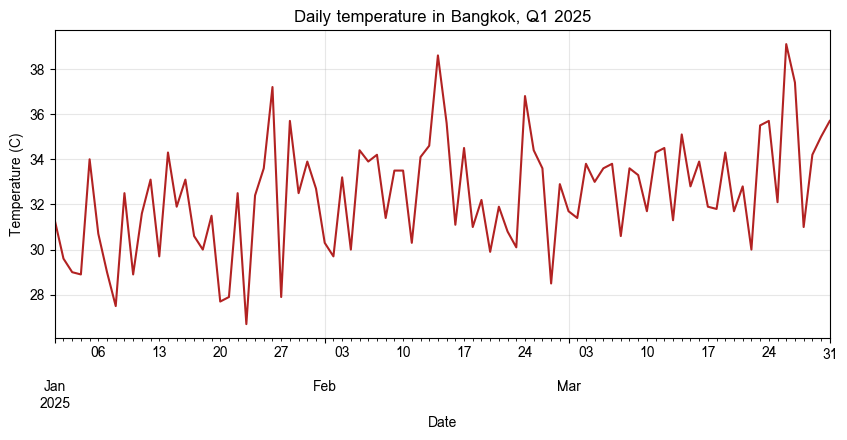

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

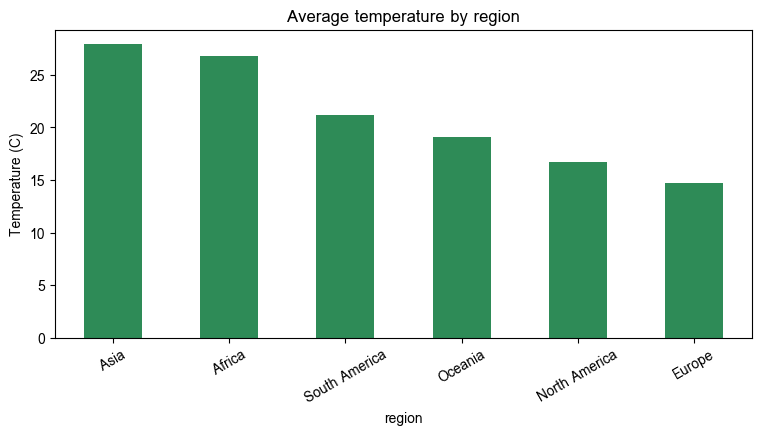

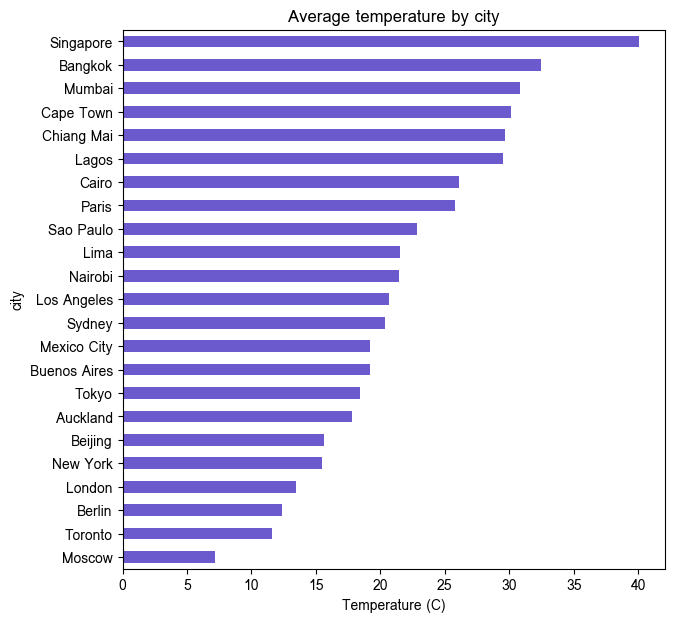

In [102]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

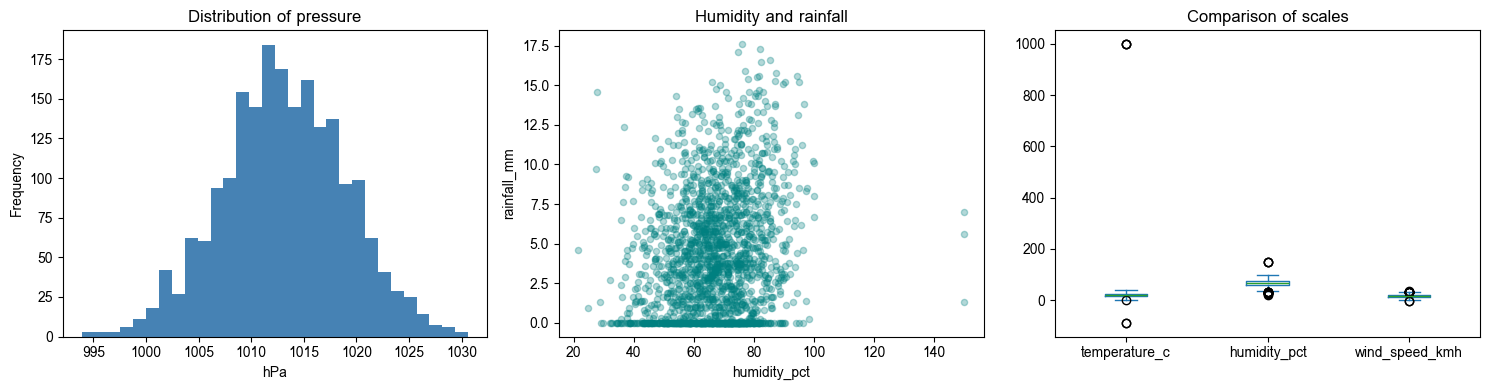

In [103]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

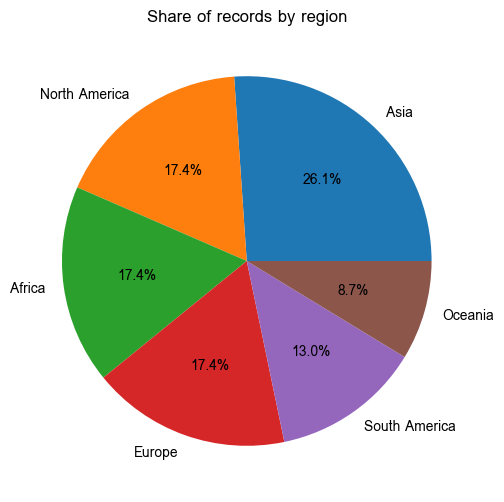

In [104]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

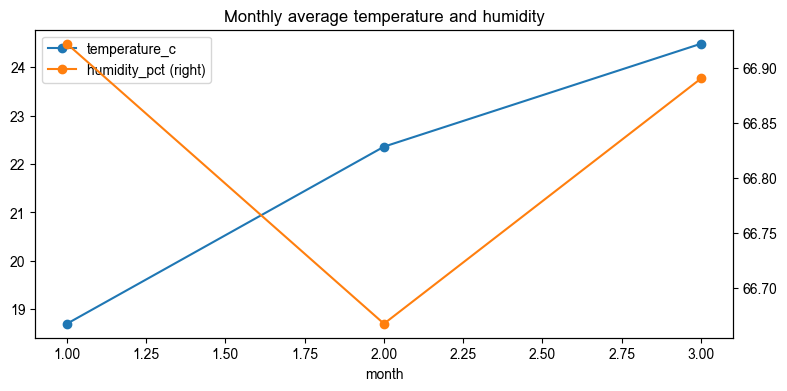

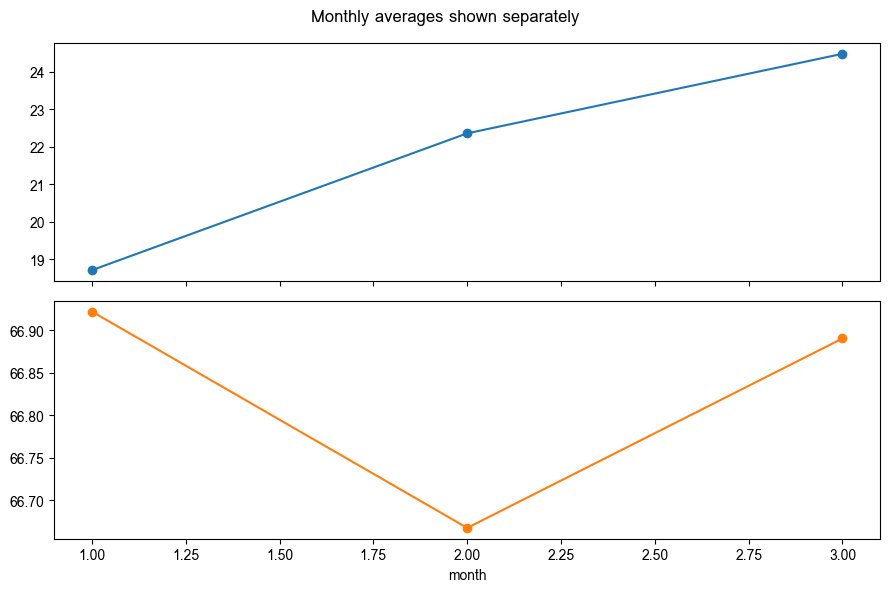

In [105]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

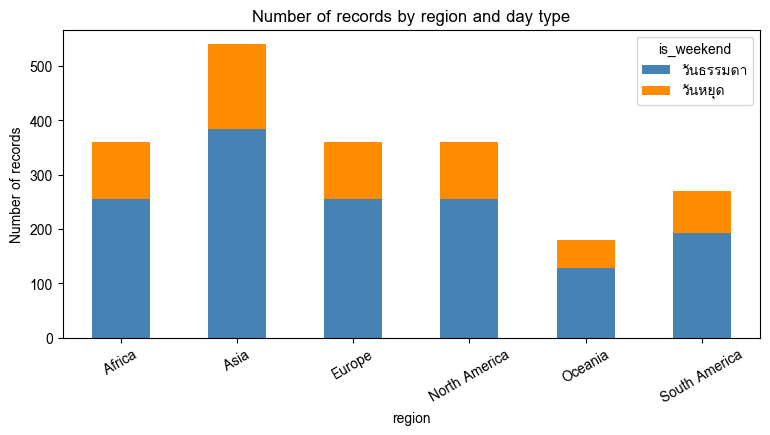

In [106]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

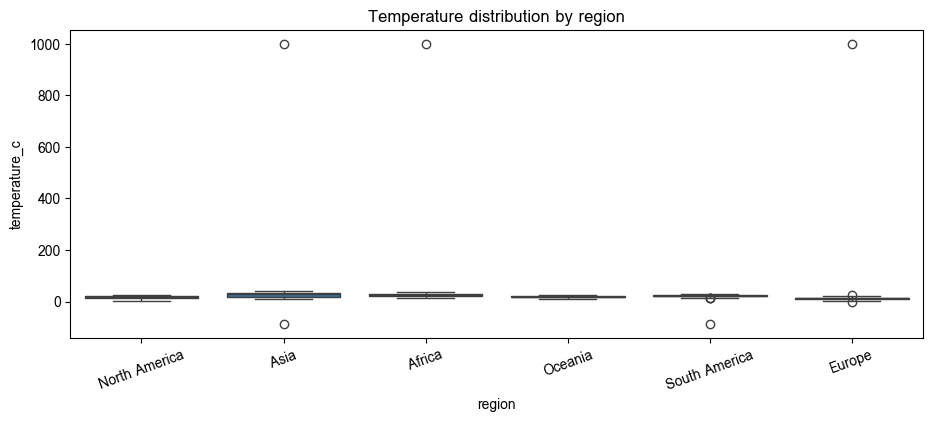

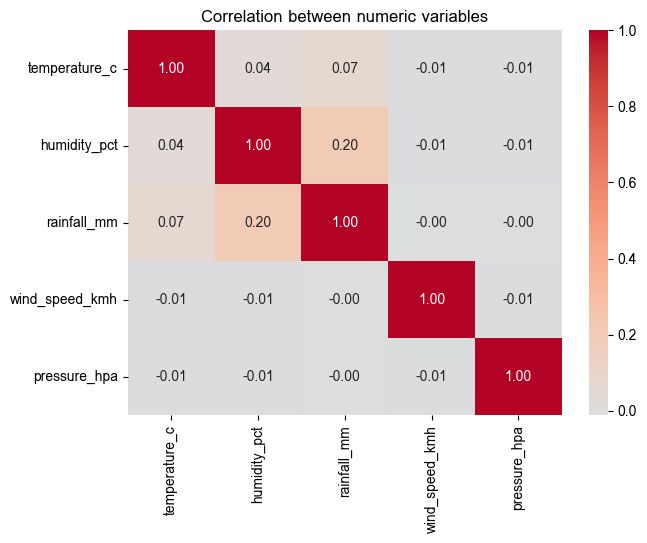

In [107]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

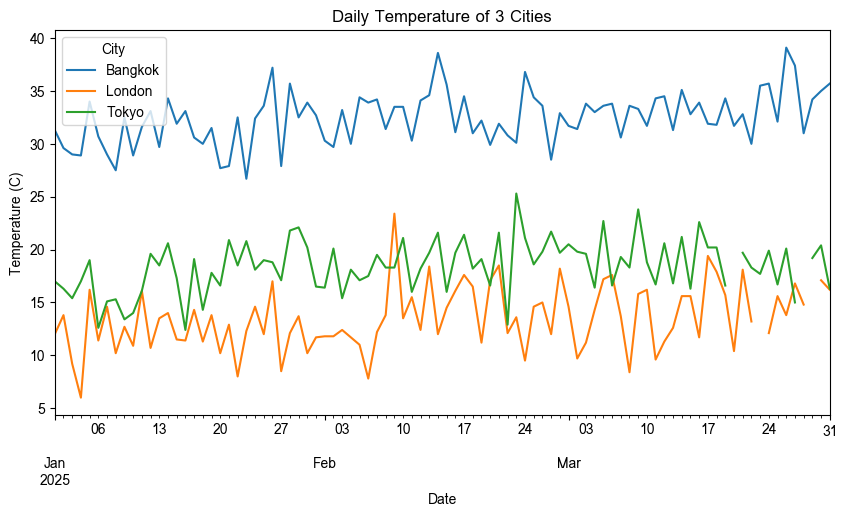

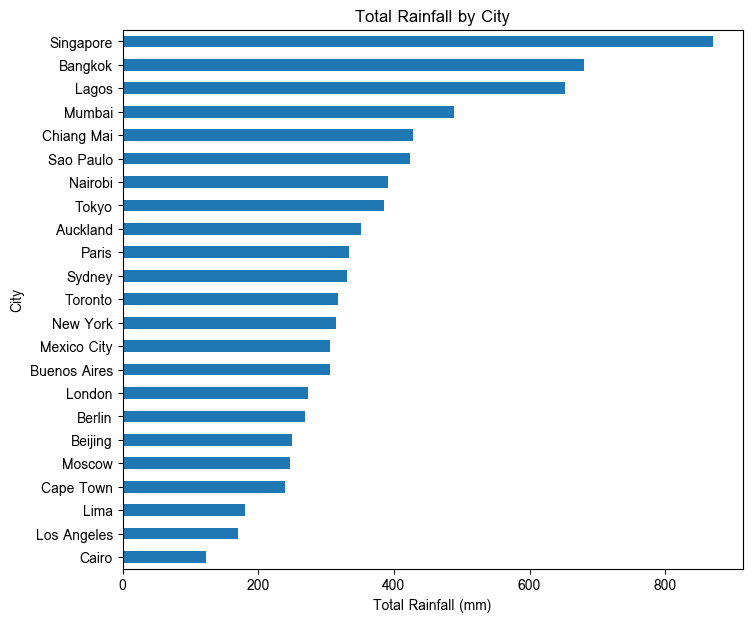

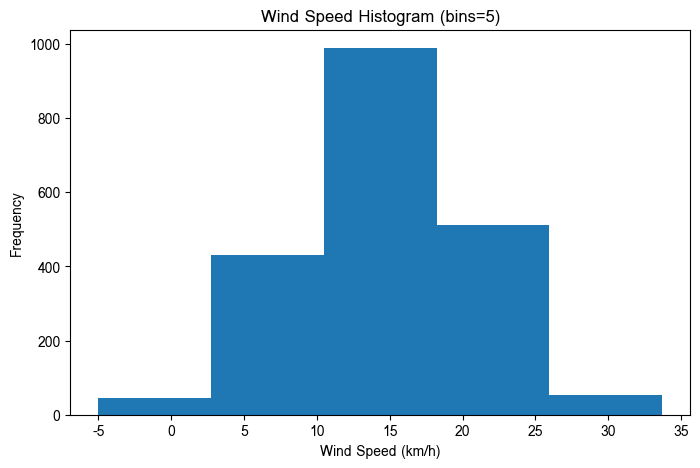

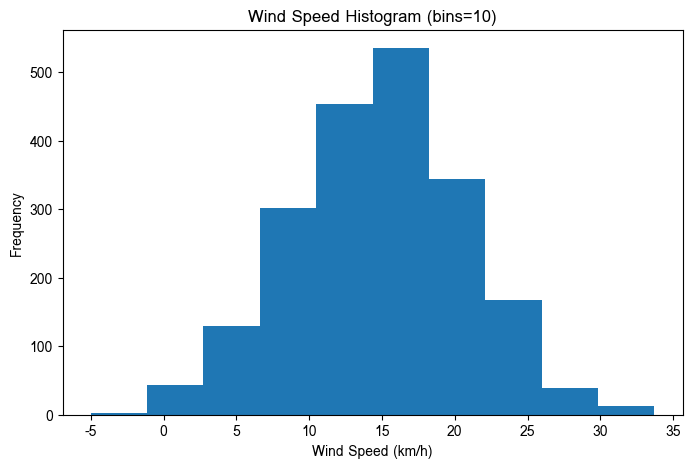

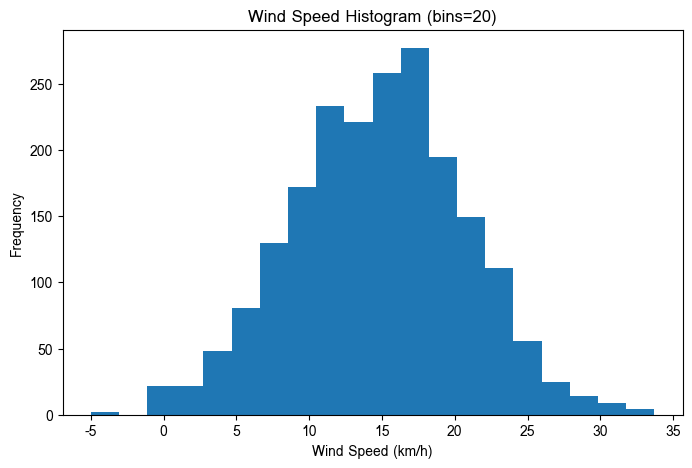

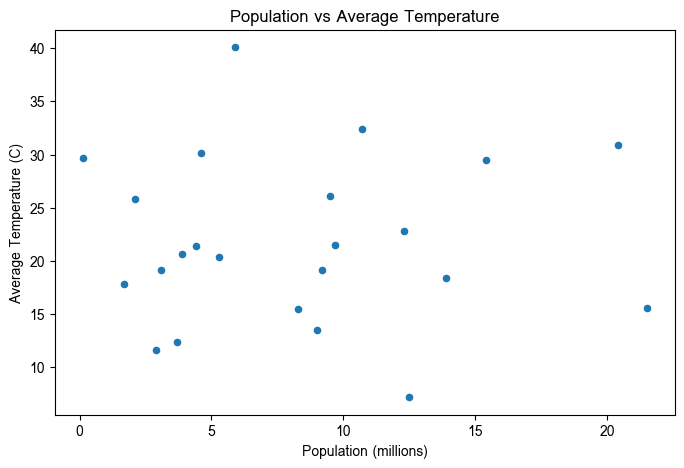

In [108]:
# คำตอบข้อ 17.1

import matplotlib.pyplot as plt

# 1) กราฟเส้นอุณหภูมิรายวันของ 3 เมือง
cities = ["Bangkok", "Tokyo", "London"]

temp_3cities = (
    df[df["city"].isin(cities)]
    .pivot(index="date", columns="city", values="temperature_c")
)

temp_3cities.plot(figsize=(10, 5))
plt.title("Daily Temperature of 3 Cities")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend(title="City")
plt.show()


# 2) กราฟแท่งแนวนอนปริมาณฝนรวมรายเมือง
rain_city = (
    df.groupby("city")["rainfall_mm"]
      .sum()
      .sort_values(ascending=True)
)

rain_city.plot(kind="barh", figsize=(8, 7))
plt.title("Total Rainfall by City")
plt.xlabel("Total Rainfall (mm)")
plt.ylabel("City")
plt.show()


# 3) Histogram wind_speed_kmh ลอง 3 ค่า bins
for b in [5, 10, 20]:
    df["wind_speed_kmh"].plot(
        kind="hist",
        bins=b,
        figsize=(8, 5)
    )
    plt.title(f"Wind Speed Histogram (bins={b})")
    plt.xlabel("Wind Speed (km/h)")
    plt.ylabel("Frequency")
    plt.show()


# 4) Scatter population กับอุณหภูมิเฉลี่ยรายเมือง
city_temp = (
    df.groupby("city")["temperature_c"]
      .mean()
      .reset_index()
)

city_temp = city_temp.merge(
    city_info[["city", "population_millions"]],
    on="city",
    how="left"
)

city_temp.plot(
    kind="scatter",
    x="population_millions",
    y="temperature_c",
    figsize=(8, 5)
)

plt.title("Population vs Average Temperature")
plt.xlabel("Population (millions)")
plt.ylabel("Average Temperature (C)")
plt.show()


### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

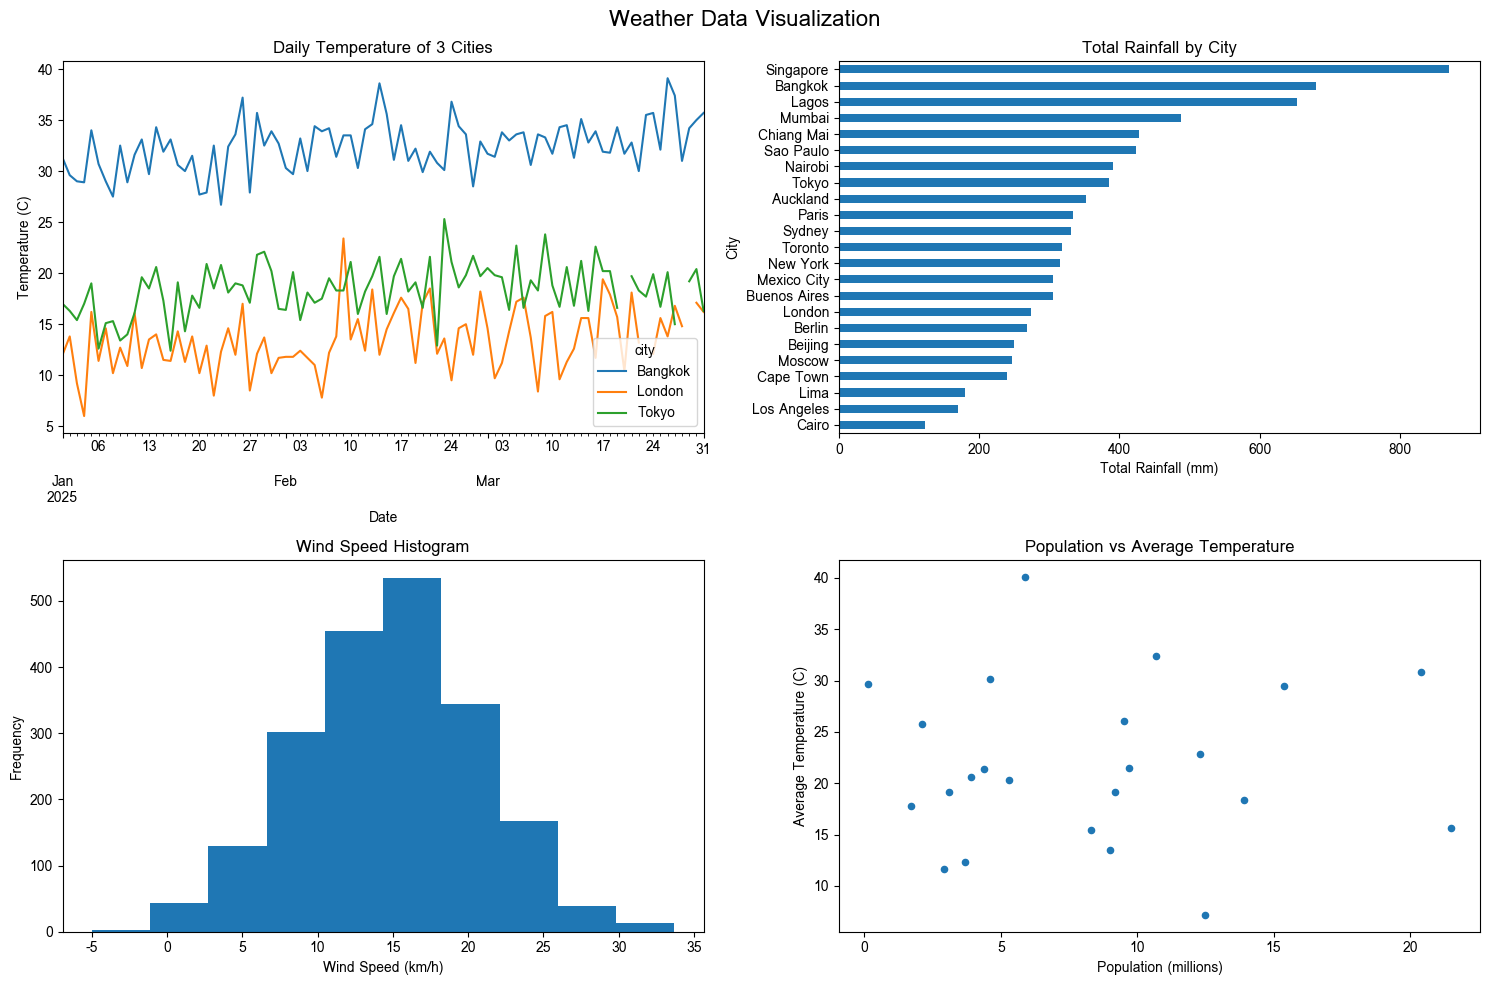

In [109]:
# คำตอบข้อ 17.2

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) กราฟเส้น
temp_3cities.plot(ax=axes[0, 0])
axes[0, 0].set_title("Daily Temperature of 3 Cities")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Temperature (C)")

# 2) กราฟแท่งแนวนอน
rain_city.plot(kind="barh", ax=axes[0, 1])
axes[0, 1].set_title("Total Rainfall by City")
axes[0, 1].set_xlabel("Total Rainfall (mm)")
axes[0, 1].set_ylabel("City")

# 3) Histogram
df["wind_speed_kmh"].plot(
    kind="hist",
    bins=10,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Wind Speed Histogram")
axes[1, 0].set_xlabel("Wind Speed (km/h)")
axes[1, 0].set_ylabel("Frequency")

# 4) Scatter plot
city_temp.plot(
    kind="scatter",
    x="population_millions",
    y="temperature_c",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Population vs Average Temperature")
axes[1, 1].set_xlabel("Population (millions)")
axes[1, 1].set_ylabel("Average Temperature (C)")

plt.suptitle("Weather Data Visualization", fontsize=16)
plt.tight_layout()
plt.show()


### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

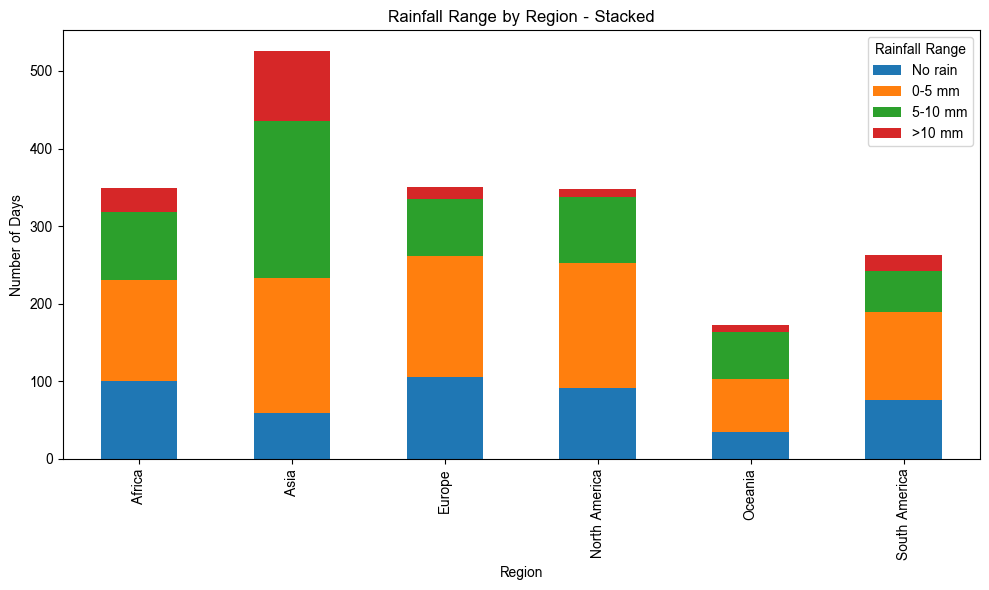

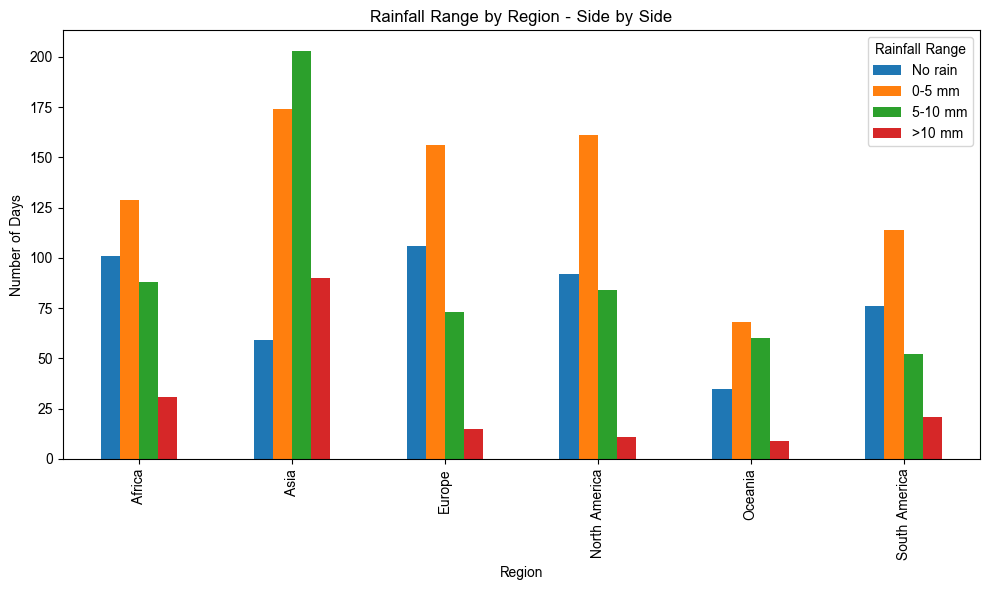

In [110]:
# คำตอบข้อ 17.3

df_173 = df.copy()

# แบ่งช่วงปริมาณฝน
df_173["rain_range"] = pd.cut(
    df_173["rainfall_mm"],
    bins=[-0.1, 0, 5, 10, float("inf")],
    labels=["No rain", "0-5 mm", "5-10 mm", ">10 mm"]
)

rain_region = pd.crosstab(
    df_173["region"],
    df_173["rain_range"]
)

# กราฟแท่งซ้อน
rain_region.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Rainfall Range by Region - Stacked")
plt.xlabel("Region")
plt.ylabel("Number of Days")
plt.legend(title="Rainfall Range")
plt.tight_layout()
plt.show()


# กราฟแท่งเรียงข้างกัน
rain_region.plot(
    kind="bar",
    stacked=False,
    figsize=(10, 6)
)

plt.title("Rainfall Range by Region - Side by Side")
plt.xlabel("Region")
plt.ylabel("Number of Days")
plt.legend(title="Rainfall Range")
plt.tight_layout()
plt.show()


กราฟแท่งซ้อนเหมาะตอนอยากดูภาพรวมว่าแต่ละภูมิภาคมีสัดส่วนช่วงฝนแบบไหนบ้างในแท่งเดียว

ส่วนกราฟแท่งเรียงข้างกันเหมาะตอนอยากเทียบแต่ละช่วงฝนให้เห็นชัด ๆ ว่าช่วงไหนมากหรือน้อยกว่ากัน

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

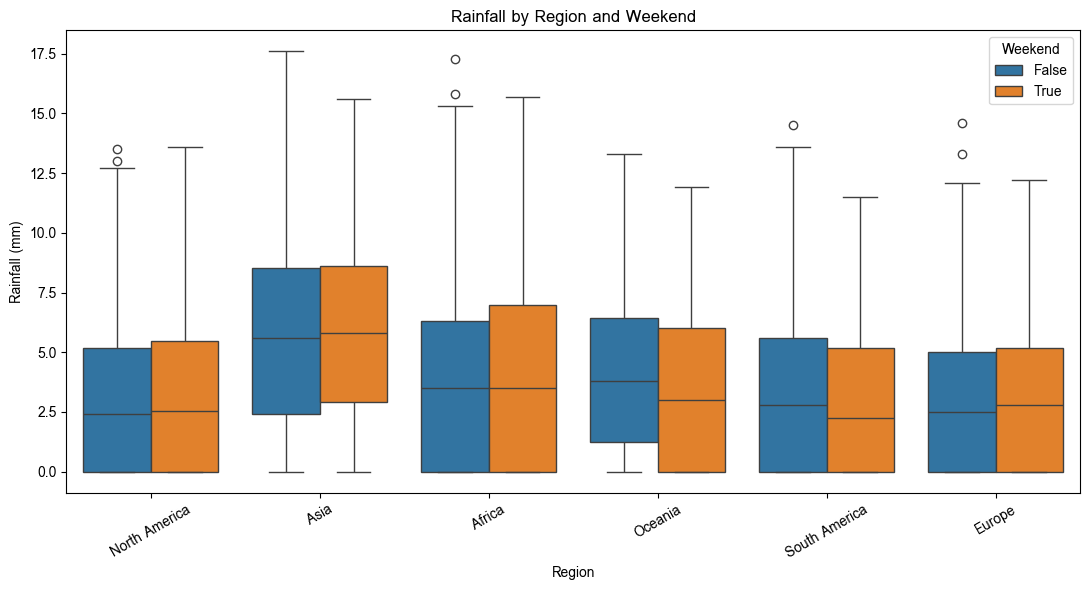

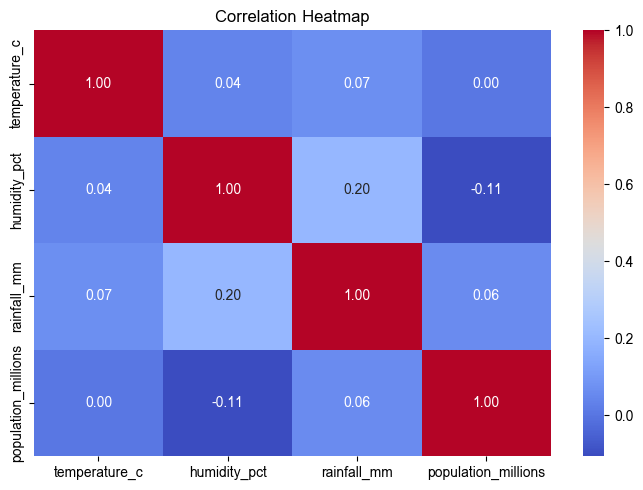

,temperature_c,humidity_pct,rainfall_mm,population_millions
temperature_c,1.000000,0.038274,0.067715,0.002578
humidity_pct,0.038274,1.000000,0.198903,-0.106284
rainfall_mm,0.067715,0.198903,1.000000,0.061099
population_millions,0.002578,-0.106284,0.061099,1.000000


In [111]:
# คำตอบข้อ 17.4

import seaborn as sns
import matplotlib.pyplot as plt

df_174 = df.copy()

# ถ้ายังไม่มี is_weekend ให้สร้างก่อน
df_174["date"] = pd.to_datetime(df_174["date"])

if "is_weekend" not in df_174.columns:
    df_174["is_weekend"] = df_174["date"].dt.dayofweek >= 5

# 1) Boxplot
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df_174,
    x="region",
    y="rainfall_mm",
    hue="is_weekend"
)

plt.title("Rainfall by Region and Weekend")
plt.xlabel("Region")
plt.ylabel("Rainfall (mm)")
plt.legend(title="Weekend")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# เพิ่ม population_millions สำหรับทำ heatmap
df_174 = df_174.merge(
    city_info[["city", "population_millions"]],
    on="city",
    how="left"
)

# 2) Heatmap
corr = df_174[
    [
        "temperature_c",
        "humidity_pct",
        "rainfall_mm",
        "population_millions"
    ]
].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

display(corr)


Boxplot: วันธรรมดากับวันหยุดปริมาณฝนไม่ได้ต่างกันมาก แต่ Asia จะดูมีฝนเยอะกว่าหลายภูมิภาค แล้วก็มีบางวันที่ฝนเยอะกว่าปกติอยู่บ้าง

Heatmap: โดยรวมตัวแปรต่าง ๆ ไม่ได้สัมพันธ์กันมาก เพราะค่าค่อนข้างใกล้ 0 มีที่เห็นชัดสุดคือความชื้นกับปริมาณฝนประมาณ 0.20 คือความชื้นมากขึ้น ฝนอาจมากขึ้นนิดหน่อย แต่ก็ไม่ได้สัมพันธ์กันแรงมาก

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

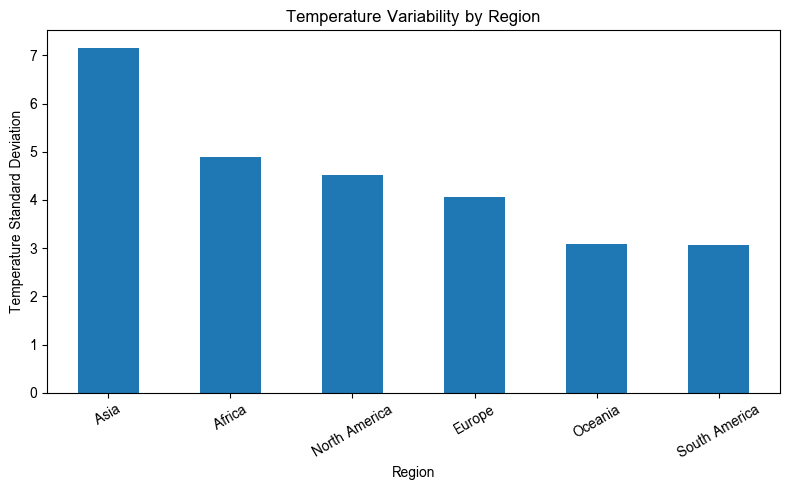

ภูมิภาคที่แปรปรวนที่สุด = Asia
เมืองที่แปรปรวนที่สุด = Beijing
std ของเมือง = 2.8747922605587948


In [112]:
# คำตอบข้อ 18.1

df_181 = df[df["temperature_c"].between(-50, 60)].copy()

region_std = (
    df_181.groupby("region")["temperature_c"]
    .std()
    .sort_values(ascending=False)
)

region_std.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Temperature Variability by Region")
plt.xlabel("Region")
plt.ylabel("Temperature Standard Deviation")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

top_region = region_std.index[0]

city_std = (
    df_181[df_181["region"] == top_region]
    .groupby("city")["temperature_c"]
    .std()
    .sort_values(ascending=False)
)

print("ภูมิภาคที่แปรปรวนที่สุด =", top_region)
print("เมืองที่แปรปรวนที่สุด =", city_std.index[0])
print("std ของเมือง =", city_std.iloc[0])

ภูมิภาคที่อุณหภูมิแปรปรวนที่สุดคือ Asia โดยมีค่า std ประมาณ 11.43 และเมืองที่แปรปรวนที่สุดในภูมิภาคนี้คือ Beijing ที่ประมาณ 2.87

แปลว่าความแปรปรวนของ Asia ไม่ได้เกิดจาก Beijing เมืองเดียวทั้งหมด แต่มีผลจากหลายเมืองรวมกัน

ในการคำนวณนี้ตัดค่าอุณหภูมิที่ต่ำกว่า -50 หรือสูงกว่า 60 ออกก่อน เพราะมองว่าเป็นค่าผิดปกติ

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

เกณฑ์ฝนตกหนักคือ rainfall_mm > 10

In [113]:
# คำตอบข้อ 18.2

df_182 = merged_141.copy()

rain_summary = (
    df_182.groupby("city")
    .agg(
        heavy_rain_days=("rainfall_mm", lambda x: (x > 10).sum()),
        rain_days=("rainfall_mm", "count")
    )
)

rain_summary["heavy_rain_ratio"] = (
    rain_summary["heavy_rain_days"] / rain_summary["rain_days"]
)

top_ratio = (
    rain_summary
    .sort_values("heavy_rain_ratio", ascending=False)
    .head(5)
    .reset_index()
)

top_days = (
    rain_summary
    .sort_values("heavy_rain_days", ascending=False)
    .head(5)
    .reset_index()
)

result_182 = pd.DataFrame({
    "อันดับ": range(1, 6),
    "เมืองตามสัดส่วน": top_ratio["city"],
    "สัดส่วนฝนหนัก": top_ratio["heavy_rain_ratio"],
    "เมืองตามจำนวนวัน": top_days["city"],
    "จำนวนวันฝนหนัก": top_days["heavy_rain_days"]
})

display(result_182)


,อันดับ,เมืองตามสัดส่วน,สัดส่วนฝนหนัก,เมืองตามจำนวนวัน,จำนวนวันฝนหนัก
0,1,Singapore,0.488889,Singapore,44
1,2,Bangkok,0.264368,Bangkok,23
2,3,Lagos,0.250000,Lagos,22
3,4,Sao Paulo,0.125000,Sao Paulo,11
4,5,Chiang Mai,0.105882,Chiang Mai,9


อันดับที่ได้จาก สัดส่วน กับ จำนวนวัน เหมือนกันหมดเลย โดย Singapore มากที่สุด รองลงมาคือ Bangkok, Lagos, Sao Paulo และ Chiang Mai

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

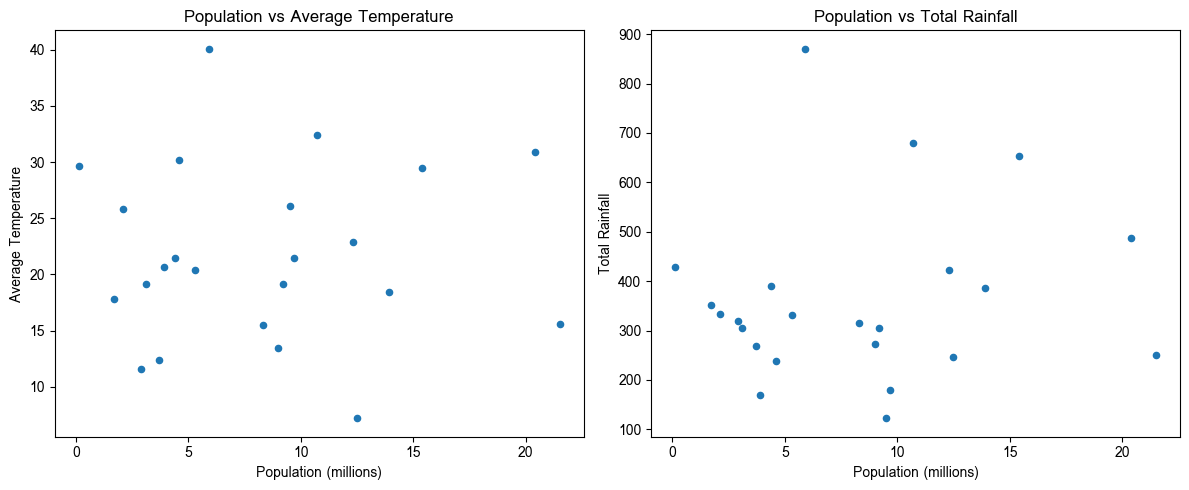

Correlation ประชากรกับอุณหภูมิ = 0.013861740039470076
Correlation ประชากรกับฝน = 0.1280743614024418


In [114]:
# คำตอบข้อ 18.3

city_183 = (
    merged_141.groupby("city")
    .agg(
        population_millions=("population_millions", "first"),
        avg_temperature=("temperature_c", "mean"),
        total_rainfall=("rainfall_mm", "sum")
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

city_183.plot(
    kind="scatter",
    x="population_millions",
    y="avg_temperature",
    ax=axes[0]
)

axes[0].set_title("Population vs Average Temperature")
axes[0].set_xlabel("Population (millions)")
axes[0].set_ylabel("Average Temperature")

city_183.plot(
    kind="scatter",
    x="population_millions",
    y="total_rainfall",
    ax=axes[1]
)

axes[1].set_title("Population vs Total Rainfall")
axes[1].set_xlabel("Population (millions)")
axes[1].set_ylabel("Total Rainfall")

plt.tight_layout()
plt.show()

print(
    "Correlation ประชากรกับอุณหภูมิ =",
    city_183["population_millions"].corr(city_183["avg_temperature"])
)

print(
    "Correlation ประชากรกับฝน =",
    city_183["population_millions"].corr(city_183["total_rainfall"])
)

จำนวนประชากรแทบไม่สัมพันธ์กับอุณหภูมิเลย เพราะค่า correlation ประมาณ -0.058 ซึ่งใกล้ 0 มาก
ส่วนกับปริมาณฝนก็สัมพันธ์กันน้อยเหมือนกัน โดยมีค่า correlation ประมาณ 0.128
ดังนั้นจากข้อมูลนี้ยังบอกไม่ได้ว่าคนเยอะแล้วจะร้อนขึ้นหรือฝนมากขึ้นแบบชัดเจน ข้อควรระวังคือ correlation แค่บอกความสัมพันธ์ ไม่ได้แปลว่าอันหนึ่งเป็นสาเหตุของอีกอัน

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

เลือกใช้ ปริมาณฝนรวม เป็นเกณฑ์

In [115]:
# คำตอบข้อ 18.4

df_184 = merged_141.copy()

df_184["month"] = pd.to_datetime(df_184["date"]).dt.month

rain_month = (
    df_184.groupby(["region", "month"])["rainfall_mm"]
    .sum()
    .reset_index()
)

worst_month = (
    rain_month.loc[
        rain_month.groupby("region")["rainfall_mm"].idxmax()
    ]
    .sort_values("region")
    .reset_index(drop=True)
)

display(worst_month)


,region,month,rainfall_mm
0,Africa,1,506.8
1,Asia,2,1043.2
2,Europe,1,399.6
3,North America,1,422.2
4,Oceania,3,240.7
5,South America,3,307.2


จากเกณฑ์ที่ใช้ เดือนที่ฝนรวมเยอะที่สุด เป็นเดือนที่ควรหลีกเลี่ยง จะได้ว่า Africa, Europe และ North America ควรเลี่ยง เดือน 1, Asia ควรเลี่ยง เดือน 2, ส่วน Oceania กับ South America ควรเลี่ยง เดือน 3

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️